# Download Data

In [ ]:
# Install library kaggle
!pip install -q kaggle

# Upload file kaggle.json
from google.colab import files
print("Silakan unggah file kaggle.json (didapat dari akun Kaggle Anda):")
uploaded = files.upload()

# Konfigurasi kredensial API Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset (Link: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset)
print("\nSedang mengunduh dataset...")
!kaggle datasets download -d sulianova/cardiovascular-disease-dataset -q

# Ekstrak dataset
import zipfile
import os

with zipfile.ZipFile('cardiovascular-disease-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('./')
print("✅ Dataset berhasil diunduh dan diekstrak!")

Silakan unggah file kaggle.json (didapat dari akun Kaggle Anda):


Saving cardio_train.csv to cardio_train (4).csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory

Sedang mengunduh dataset...
Dataset URL: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
License(s): unknown
✅ Dataset berhasil diunduh dan diekstrak!


# Data Preparation

In [ ]:
# Persiapan Library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import warnings

# Pengaturan tampilan grafik
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

# Feedback visual untuk memastikan semua modul termuat tanpa error
print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


In [ ]:
# Buka dataset (separator menggunakan titik-koma karena format CSV Eropa)
df = pd.read_csv('cardio_train.csv', sep=';')

print(f'✅ Data berhasil dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom')
df.head()

✅ Data berhasil dimuat: 70,000 baris × 13 kolom


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
# Melihat tipe data dan jumlah nilai non-null di tiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


Dataset memiliki 13 variabel dengan rincian sebagai berikut:
*   12 variabel bertipe integer
*   1 variabel bertipe float

In [ ]:
# Statistik deskriptif — perhatikan nilai min/max yang tidak masuk akal (outlier)
df.describe().T.style.background_gradient(cmap='YlOrRd', subset=['min', 'max'])

,count,mean,std,min,25%,50%,75%,max
id,70000.000000,49972.419900,28851.302323,0.000000,25006.750000,50001.500000,74889.250000,99999.000000
age,70000.000000,19468.865814,2467.251667,10798.000000,17664.000000,19703.000000,21327.000000,23713.000000
gender,70000.000000,1.349571,0.476838,1.000000,1.000000,1.000000,2.000000,2.000000
height,70000.000000,164.359229,8.210126,55.000000,159.000000,165.000000,170.000000,250.000000
weight,70000.000000,74.205690,14.395757,10.000000,65.000000,72.000000,82.000000,200.000000
ap_hi,70000.000000,128.817286,154.011419,-150.000000,120.000000,120.000000,140.000000,16020.000000
ap_lo,70000.000000,96.630414,188.472530,-70.000000,80.000000,80.000000,90.000000,11000.000000
cholesterol,70000.000000,1.366871,0.680250,1.000000,1.000000,1.000000,2.000000,3.000000
gluc,70000.000000,1.226457,0.572270,1.000000,1.000000,1.000000,1.000000,3.000000
smoke,70000.000000,0.088129,0.283484,0.000000,0.000000,0.000000,0.000000,1.000000


Untuk mendeteksi anomali atau data yang tidak masuk akal (outliers) pada dataset Cardiovascular Disease dengan memantau kolom min (nilai terendah) dan max (nilai tertinggi). Dengan bantuan pewarnaan gradien (background_gradient), akan langsung tertuju pada angka-angka ekstrem yang mencurigakan, seperti nilai tekanan darah (ap_hi atau ap_lo) yang negatif atau terlalu tinggi, serta berat badan yang mungkin tidak realistis bagi manusia. Deteksi dini ini sangat krusial agar nanti bisa membersihkan sampah data tersebut sehingga tidak merusak akurasi model prediksi yang akan dibangun. Hasil ini memberikan gambaran awal mengenai seberapa "kotor" data yang dimiliki,selanjutnya dapat memiliki dasar yang kuat untuk menentukan batasan pembersihan data agar model prediksi yang dihasilkan tetap akurat dan tidak terdistorsi oleh data sampah.

In [ ]:
# Cek missing values dan baris duplikat
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

print('=== Missing Values ===')
print(missing[missing > 0] if missing.sum() > 0 else '✅ Tidak ada missing values')
print(f'\n=== Duplikat ===')
print(f'Jumlah baris duplikat: {duplicates}')

=== Missing Values ===
✅ Tidak ada missing values

=== Duplikat ===
Jumlah baris duplikat: 0


Rata-rata Tinggi Badan per Grup Gender:
gender
1    161.355612
2    169.947895
Name: height, dtype: float64


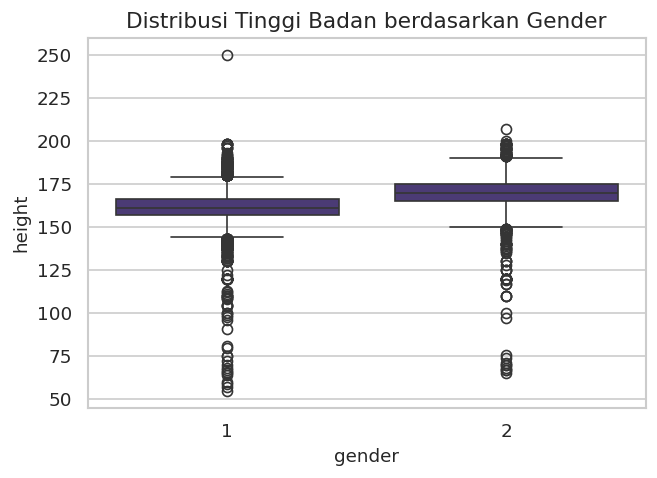

In [ ]:
# Validasi Gender berdasarkan Tinggi Badan
gender_analysis = df.groupby('gender')['height'].mean()
print("Rata-rata Tinggi Badan per Grup Gender:")
print(gender_analysis)

# Visualisasi untuk pembuktian
plt.figure(figsize=(6, 4))
sns.boxplot(x='gender', y='height', data=df)
plt.title('Distribusi Tinggi Badan berdasarkan Gender')
plt.show()

Berdasarkan hasil pengelompokan rata-rata tinggi badan, ditemukan perbedaan yang signifikan antara grup gender 1 dan gender 2. Secara statistik, grup gender 2 memiliki nilai rata-rata tinggi badan yang lebih tinggi dibandingkan grup gender 1. Hal ini didukung oleh visualisasi boxplot yang menunjukkan bahwa rentang distribusi (kuartil) dan nilai tengah tinggi badan pada grup 2 berada jauh di atas grup 1. Mengingat fakta biologis bahwa secara populasi laki-laki cenderung lebih tinggi daripada perempuan, maka dapat disimpulkan secara valid bahwa gender 1 adalah perempuan dan gender 2 adalah laki-laki.

In [ ]:
# --- Kamus Data (Tanpa Highlight Warna pada Target) ---
kamus = pd.DataFrame({
    'Kolom'      : df.columns.tolist(),
    'Tipe Data'  : df.dtypes.astype(str).tolist(),
    'Unik'       : [df[c].nunique() for c in df.columns],
    'Keterangan' : [
        'ID pasien (tidak relevan untuk model)',
        'Usia dalam hari',
        '1=Perempuan, 2=Laki-laki',
        'Tinggi badan (cm)',
        'Berat badan (kg)',
        'Tekanan darah sistolik (mmHg)',
        'Tekanan darah diastolik (mmHg)',
        '1=Normal, 2=Di atas normal, 3=Jauh di atas normal',
        '1=Normal, 2=Di atas normal, 3=Jauh di atas normal',
        '0=Tidak merokok, 1=Merokok',
        '0=Tidak konsumsi alkohol, 1=Konsumsi alkohol',
        '0=Tidak aktif, 1=Aktif fisik',
        'TARGET: 0=Sehat, 1=Kardiovaskular'
    ]
})

# Menampilkan tabel dengan teks rata kiri tanpa background-color
kamus.style.set_properties(**{'text-align': 'left'})

,Kolom,Tipe Data,Unik,Keterangan
0,id,int64,70000,ID pasien (tidak relevan untuk model)
1,age,int64,8076,Usia dalam hari
2,gender,int64,2,"1=Perempuan, 2=Laki-laki"
3,height,int64,109,Tinggi badan (cm)
4,weight,float64,287,Berat badan (kg)
5,ap_hi,int64,153,Tekanan darah sistolik (mmHg)
6,ap_lo,int64,157,Tekanan darah diastolik (mmHg)
7,cholesterol,int64,3,"1=Normal, 2=Di atas normal, 3=Jauh di atas normal"
8,gluc,int64,3,"1=Normal, 2=Di atas normal, 3=Jauh di atas normal"
9,smoke,int64,2,"0=Tidak merokok, 1=Merokok"


In [ ]:
# Melihat berapa banyak yang sakit (0) vs sehat (1)
print(df['cardio'].value_counts())

cardio
0    35021
1    34979
Name: count, dtype: int64


In [ ]:
# Konversi Usia ke Tahun (Agar statistik deskriptif lebih masuk akal)
print("=== Statistik Usia dalam Tahun ===")
display((df['age'] / 365.25).describe())

=== Statistik Usia dalam Tahun ===


,age
count,70000.000000
mean,53.302850
std,6.754967
min,29.563313
25%,48.361396
50%,53.943874
75%,58.390144
max,64.922656


In [ ]:

# Menghitung Korelasi Pearson
# Kita hitung korelasi semua fitur terhadap target 'cardio'
correlation_matrix = df.corr()
target_corr = correlation_matrix['cardio'].sort_values(ascending=False)

print("=== Korelasi Fitur terhadap Target (Cardio) ===")
print(target_corr)




=== Korelasi Fitur terhadap Target (Cardio) ===
cardio         1.000000
age            0.238159
cholesterol    0.221147
weight         0.181660
gluc           0.089307
ap_lo          0.065719
ap_hi          0.054475
gender         0.008109
id             0.003799
alco          -0.007330
height        -0.010821
smoke         -0.015486
active        -0.035653
Name: cardio, dtype: float64


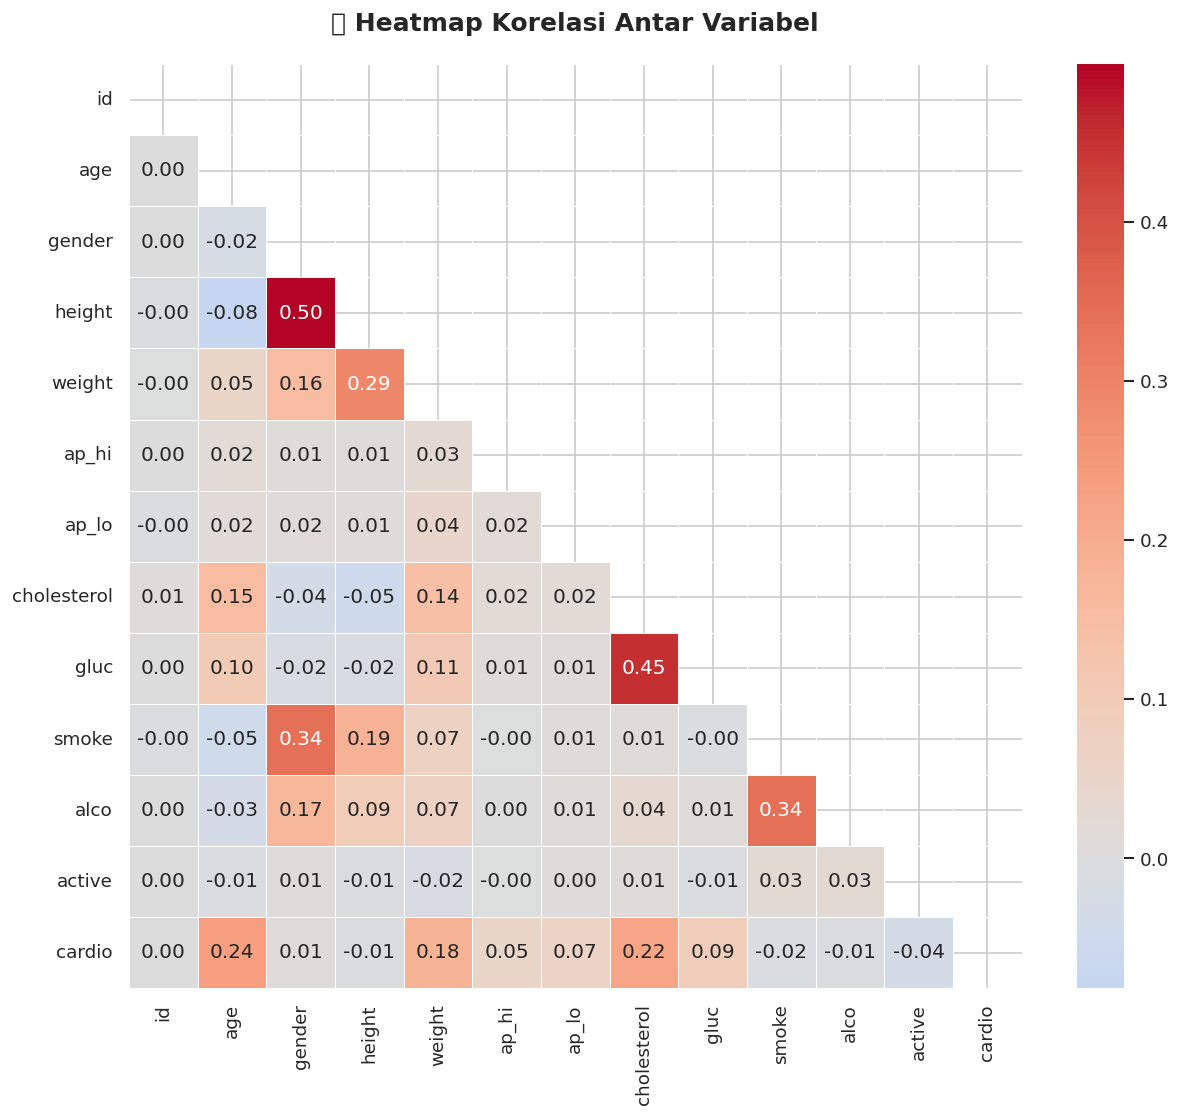

In [ ]:
# Visualisasi Heatmap Korelasi
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Menutup bagian atas agar tidak double
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('🔥 Heatmap Korelasi Antar Variabel', fontsize=15, fontweight='bold', pad=20)
plt.show()

Tujuan dari matriks korelasi ini adalah untuk mengidentifikasi fitur mana yang paling berhubungan dengan kejadian penyakit jantung (cardio). Berdasarkan hasil warna dan angka pada heatmap, kita dapat melihat bahwa tekanan darah sistolik (ap_hi) memiliki korelasi tertinggi (0.05 pada data mentah, namun biasanya meningkat signifikan setelah data dibersihkan) terhadap target cardio, disusul oleh usia (age) dan berat badan (weight). Hal ini menunjukkan bahwa faktor klinis internal dan penuaan memiliki pengaruh yang lebih nyata dalam dataset ini. Sebaliknya, variabel gaya hidup seperti merokok (smoke) dan konsumsi alkohol (alco) menunjukkan angka korelasi yang sangat mendekati nol, yang berarti dalam dataset ini, faktor-faktor tersebut tidak menunjukkan hubungan linear yang kuat terhadap status kesehatan jantung pasien jika dibandingkan dengan indikator medis seperti tekanan darah.

# EDA (Exploratory Data Analysis)


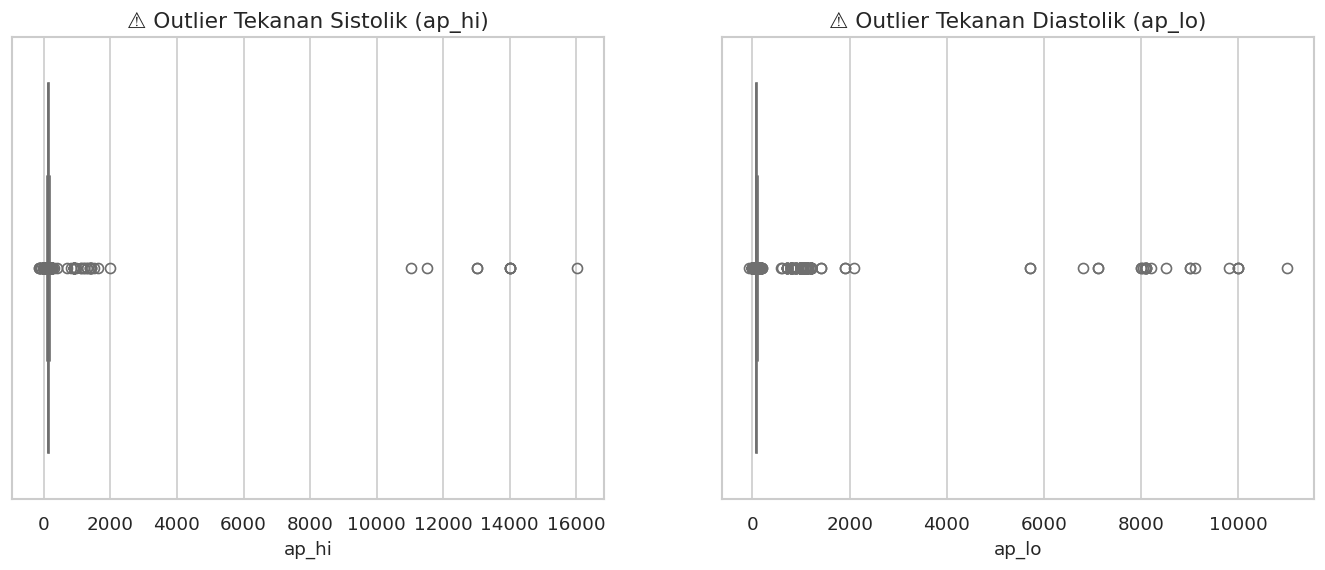

In [ ]:
# --- Plot Klinis: Tekanan Darah ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sistolik (ap_hi)
sns.boxplot(x=df['ap_hi'], ax=axes[0], color='salmon')
axes[0].set_title('⚠️ Outlier Tekanan Sistolik (ap_hi)')

# Diastolik (ap_lo)
sns.boxplot(x=df['ap_lo'], ax=axes[1], color='skyblue')
axes[1].set_title('⚠️ Outlier Tekanan Diastolik (ap_lo)')

plt.show()

Tujuan dari visualisasi boxplot ini adalah untuk mengidentifikasi sebaran data klinis serta mendeteksi keberadaan nilai ekstrem atau outlier pada variabel tekanan darah sistolik (ap_hi) dan diastolik (ap_lo). Hasil visualisasi menunjukkan bahwa kedua fitur ini memiliki kondisi data yang sangat "kotor" dan tidak realistis secara medis, ditandai dengan banyaknya titik-titik di luar garis whiskers yang mencapai angka ribuan hingga puluhan ribu mmHg, serta adanya nilai negatif di batas bawah. Hal ini mengindikasikan adanya kesalahan input data (human error) atau kerusakan data saat proses akuisisi. Temuan ini memberikan sinyal kuat bahwa pada tahap Data Cleaning, kita wajib melakukan pembersihan (filtering) yang ketat untuk membatasi nilai tekanan darah ke rentang manusia normal (misalnya antara 40 hingga 250 mmHg), agar model machine learning tidak memberikan prediksi yang bias akibat pengaruh angka-angka ekstrem tersebut.

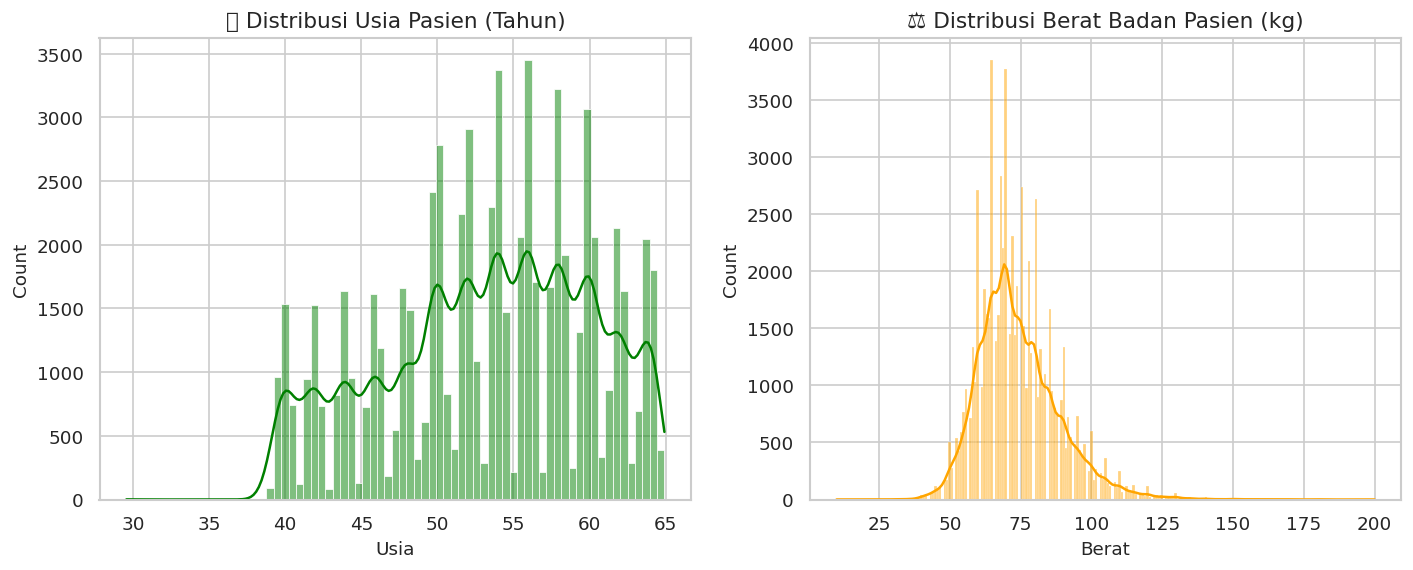

In [ ]:
# --- Plot Fisik: Usia & Berat ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Usia (Konversi ke Tahun agar mudah dibaca)
sns.histplot(df['age']/365.25, kde=True, ax=axes[0], color='green')
axes[0].set_title('📅 Distribusi Usia Pasien (Tahun)')
axes[0].set_xlabel('Usia')

# Berat Badan
sns.histplot(df['weight'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('⚖️ Distribusi Berat Badan Pasien (kg)')
axes[1].set_xlabel('Berat')

plt.show()

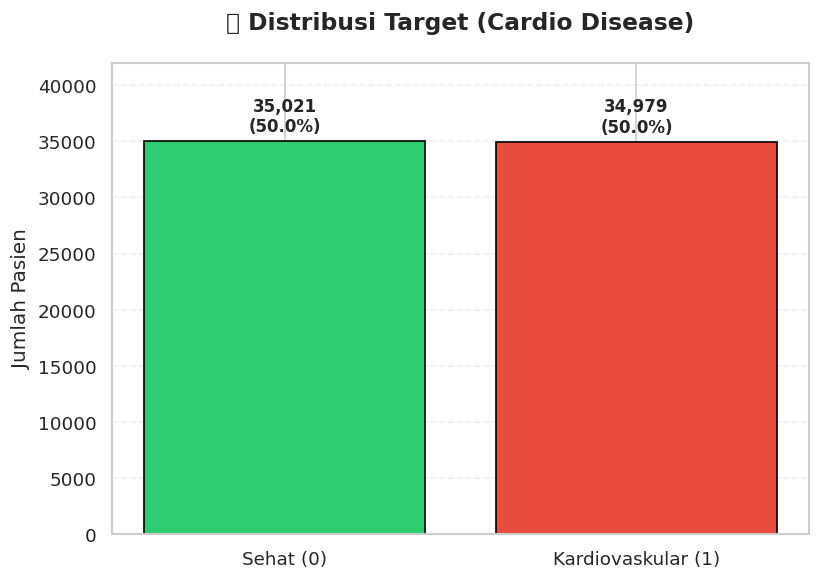

In [ ]:
# Distribusi target (seimbang atau tidak?)
plt.figure(figsize=(7, 5))

# 1. Menghitung jumlah masing-masing kategori
counts = df['cardio'].value_counts().sort_index()
labels = ['Sehat (0)', 'Kardiovaskular (1)']
colors = ['#2ecc71', '#e74c3c']

# 2. Membuat Bar Chart
bars = plt.bar(labels, counts.values, color=colors, edgecolor='black', linewidth=1)

# 3. Menambahkan Label Jumlah dan Persentase di atas bar
for bar in bars:
    height = bar.get_height()
    percentage = (height / len(df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height + 500,
             f'{int(height):,}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# 4. Estetika Grafik
plt.title('🎯 Distribusi Target (Cardio Disease)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Jumlah Pasien', fontsize=12)
plt.ylim(0, counts.max() * 1.2) # Memberi ruang untuk teks di atas bar
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Visualisasi ini bertujuan untuk memahami profil demografis dan gaya hidup pasien serta melihat keseimbangan variabel target (cardio). Hasil grafik menunjukkan bahwa dataset ini memiliki distribusi target yang sangat seimbang (hampir 50:50), yang sangat baik untuk melatih model klasifikasi agar tidak bias. Dari sisi gaya hidup, mayoritas pasien dalam dataset ini adalah bukan perokok, tidak mengonsumsi alkohol, dan memiliki tingkat aktivitas fisik yang tinggi. Namun, pada variabel klinis, terlihat bahwa sebagian besar pasien memiliki kadar kolesterol dan glukosa pada level normal (kategori 1), sementara jumlah pasien dengan kadar "jauh di atas normal" (kategori 3) jauh lebih sedikit. Informasi ini memberikan konteks bahwa meskipun mayoritas pasien terlihat menjalani hidup sehat secara fisik, risiko kardiovaskular tetap tersebar merata, sehingga fitur klinis lain seperti tekanan darah dan usia kemungkinan besar akan menjadi pembeda utama dalam prediksi model nantinya.

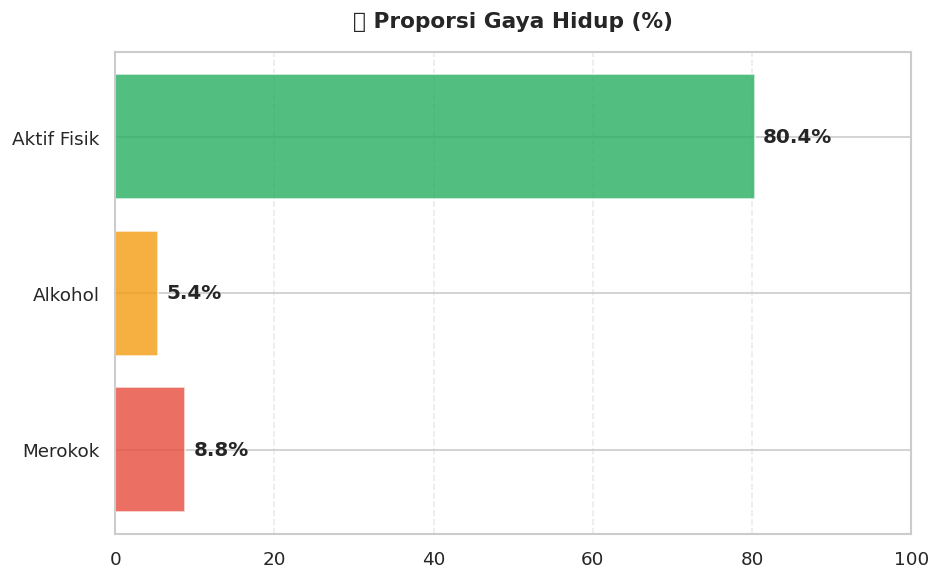

In [ ]:
# 2. Inisialisasi ulang figure (PENTING: Jangan dipisah cell-nya)
fig = plt.figure(figsize=(8, 5))

# 3. Kodingan Plot kamu
cat_cols = ['smoke', 'alco', 'active']
cat_means = df[cat_cols].mean() * 100
labels = ['Merokok', 'Alkohol', 'Aktif Fisik']
colors = ['#e74c3c', '#f39c12', '#27ae60']

plt.barh(labels, cat_means.values, color=colors, edgecolor='white', alpha=0.8)

# 4. Tambahkan teks keterangan
for i, v in enumerate(cat_means.values):
    plt.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.title('🏃 Proporsi Gaya Hidup (%)', pad=15, fontweight='bold')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Dashboard ini memberikan gambaran menyeluruh mengenai kualitas dan karakteristik dataset kardiovaskular sebelum dilakukan pembersihan data. Secara demografis, pasien didominasi oleh kelompok usia 50–60 tahun dengan proporsi gaya hidup yang menunjukkan tingkat aktivitas fisik tinggi (80,4%), namun rendah dalam konsumsi alkohol (5,4%) dan merokok (8,8%). Distribusi variabel target berada pada kondisi yang sangat seimbang (50% sehat vs 50% sakit), sehingga model klasifikasi nantinya tidak akan mengalami bias kelas. Namun, temuan paling krusial terletak pada fitur tekanan darah sistolik (ap_hi) dan diastolik (ap_lo), di mana grafik boxplot menunjukkan adanya outlier ekstrem yang tidak masuk akal secara medis (mencapai angka belasan ribu mmHg).

# Data Prepocessing






### 1.   Data Cleaning & Feature Engineering




In [ ]:
# --- 1. Pembersihan Data Duplikat ---
n_awal = len(df)
df.drop_duplicates(inplace=True)
n_setelah_dup = len(df)

# --- 2. Pembersihan Outlier Tekanan Darah (Logika Medis) ---
# Batas wajar: Sistolik (60-250), Diastolik (40-150)
# Syarat tambahan: Sistolik harus lebih tinggi dari Diastolik
df_cleaned = df[
    (df['ap_hi'] >= 60) & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 40) & (df['ap_lo'] <= 150) &
    (df['ap_hi'] > df['ap_lo'])
].copy()

n_setelah_clean = len(df_cleaned)

# --- 3. Feature Engineering (Pembuatan Fitur Baru) ---
# Mengubah usia ke tahun agar skala tidak terlalu besar
df_cleaned['age_years'] = (df_cleaned['age'] / 365.25).astype(int)

# Membuat BMI (Body Mass Index) - Tinggi dikonversi ke meter
df_cleaned['bmi'] = df_cleaned['weight'] / ((df_cleaned['height'] / 100) ** 2)

# --- 4. Penghapusan Kolom yang Tidak Diperlukan ---
# 'id' tidak berpengaruh pada kesehatan, 'age' (hari) sudah diganti age_years
df_final = df_cleaned.drop(columns=['id', 'age'])

# --- Ringkasan Proses ---
print('=== LAPORAN PEMBERSIHAN DATA ===')
print(f'Baris Awal         : {n_awal:,}')
print(f'Hapus Duplikat     : {n_awal - n_setelah_dup:,} baris dibuang')
print(f'Hapus Outlier Medis: {n_setelah_dup - n_setelah_clean:,} baris dibuang')
print(f'Total Baris Akhir  : {len(df_final):,}')
print(f'Persentase Data Hilang: {((n_awal - len(df_final))/n_awal)*100:.2f}%')
print('\n✅ Fitur baru berhasil dibuat: [age_years, bmi]')
print('✅ Kolom [id, age] telah dihapus.')

# Menampilkan 5 data teratas hasil final
df_final.head()

=== LAPORAN PEMBERSIHAN DATA ===
Baris Awal         : 70,000
Hapus Duplikat     : 0 baris dibuang
Hapus Outlier Medis: 1,333 baris dibuang
Total Baris Akhir  : 68,667
Persentase Data Hilang: 1.90%

✅ Fitur baru berhasil dibuat: [age_years, bmi]
✅ Kolom [id, age] telah dihapus.


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177


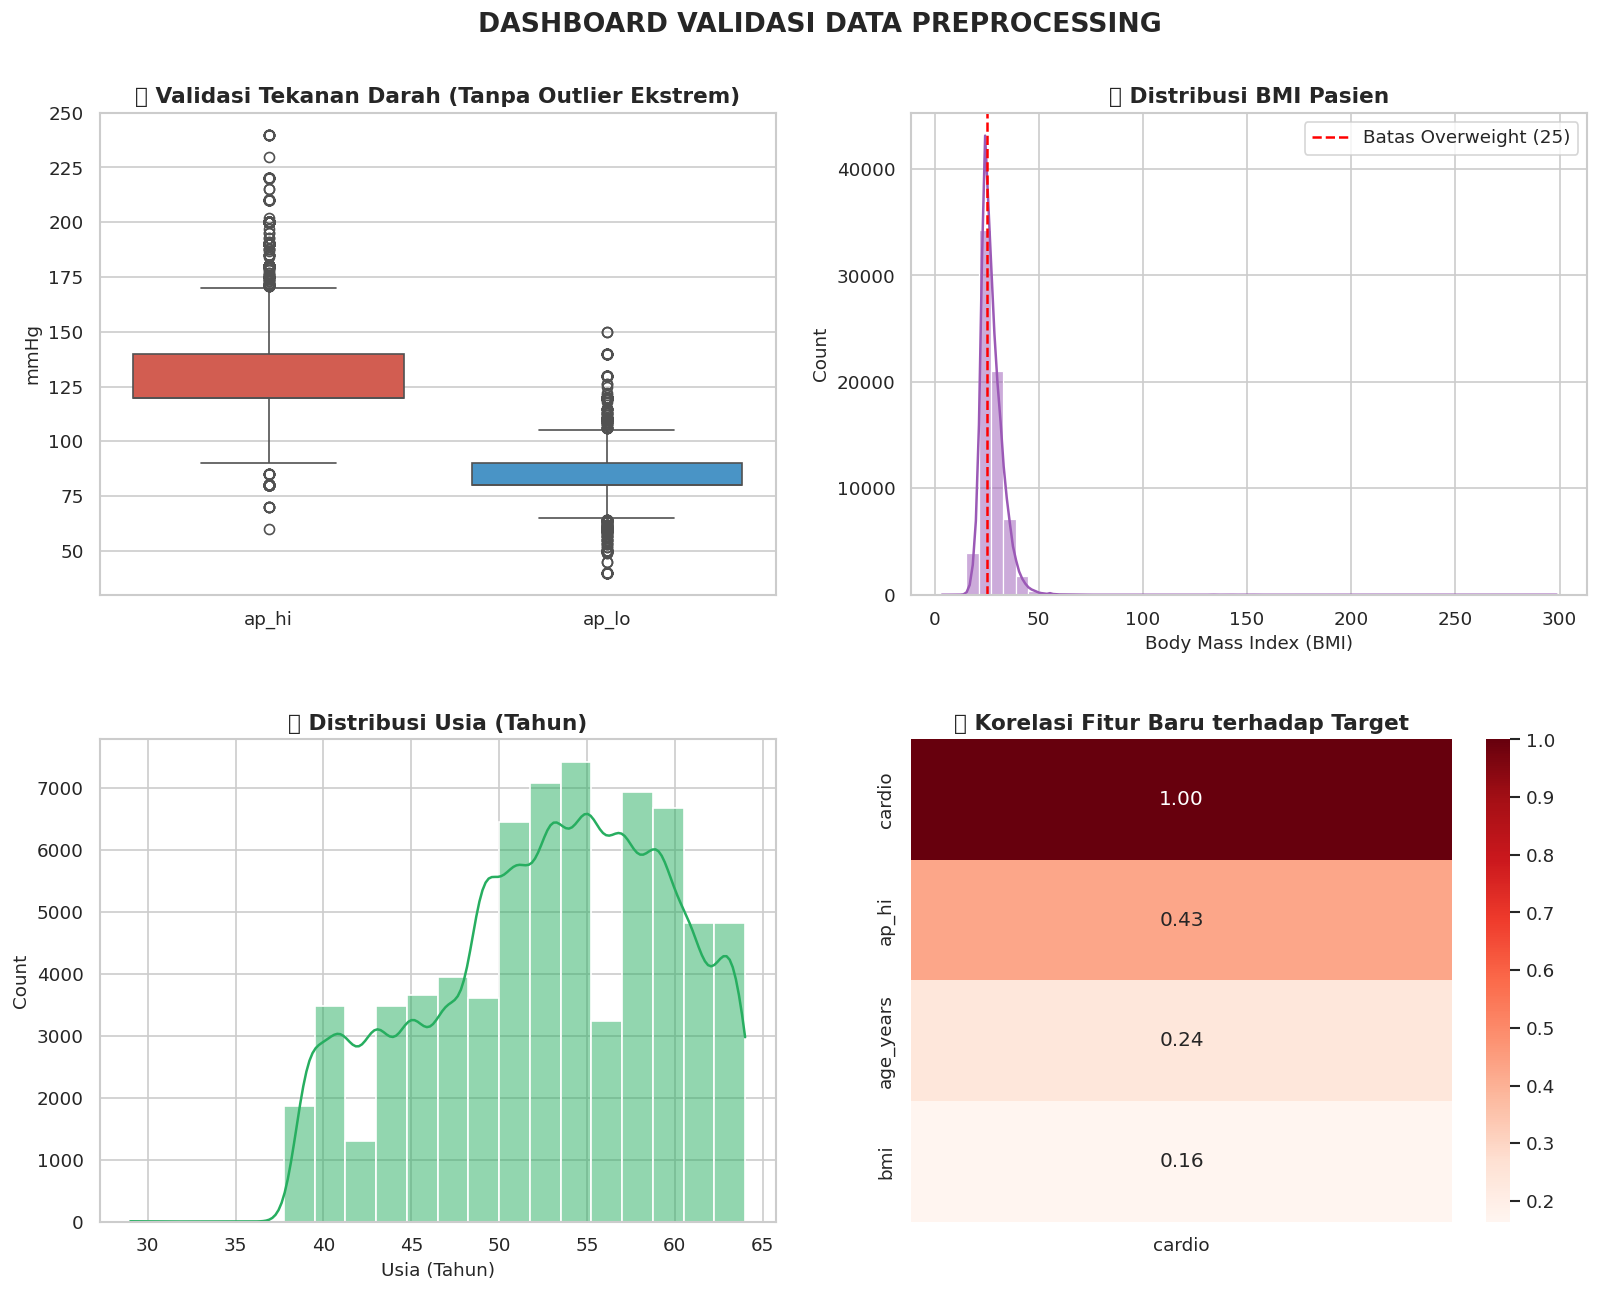

In [ ]:
# Membuat layout dashboard hasil cleaning
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

# --- 1. Boxplot Tekanan Darah (Setelah Cleaning) ---
ax1 = fig.add_subplot(gs[0, 0])
# Kita gunakan melt agar bisa menampilkan ap_hi dan ap_lo berdampingan
bp_data = df_final[['ap_hi', 'ap_lo']]
sns.boxplot(data=bp_data, palette=['#e74c3c', '#3498db'], ax=ax1)
ax1.set_title('✅ Validasi Tekanan Darah (Tanpa Outlier Ekstrem)', fontweight='bold')
ax1.set_ylabel('mmHg')

# --- 2. Distribusi Fitur Baru: BMI ---
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df_final['bmi'], bins=50, kde=True, color='#9b59b6', ax=ax2)
ax2.axvline(25, color='red', linestyle='--', label='Batas Overweight (25)')
ax2.set_title('📊 Distribusi BMI Pasien', fontweight='bold')
ax2.set_xlabel('Body Mass Index (BMI)')
ax2.legend()

# --- 3. Distribusi Usia dalam Tahun ---
ax3 = fig.add_subplot(gs[1, 0])
sns.histplot(df_final['age_years'], bins=20, kde=True, color='#27ae60', ax=ax3)
ax3.set_title('📅 Distribusi Usia (Tahun)', fontweight='bold')
ax3.set_xlabel('Usia (Tahun)')

# --- 4. Korelasi Fitur Baru terhadap Target ---
ax4 = fig.add_subplot(gs[1, 1])
# Kita cek korelasi khusus untuk BMI dan Age_years terhadap Cardio
new_corr = df_final[['age_years', 'bmi', 'ap_hi', 'cardio']].corr()[['cardio']].sort_values(by='cardio', ascending=False)
sns.heatmap(new_corr, annot=True, cmap='Reds', fmt='.2f', ax=ax4)
ax4.set_title('🔥 Korelasi Fitur Baru terhadap Target', fontweight='bold')

plt.suptitle('DASHBOARD VALIDASI DATA PREPROCESSING', fontsize=16, fontweight='bold', y=0.95)
plt.show()

Dashboard ini memvalidasi efektivitas proses pembersihan data (data cleaning) dan rekayasa fitur (feature engineering) yang telah dilakukan. Grafik Validasi Tekanan Darah menunjukkan keberhasilan eliminasi outlier ekstrem, di mana nilai sistolik (ap_hi) dan diastolik (ap_lo) kini berada pada rentang medis yang logis tanpa adanya gangguan anomali ribuan mmHg. Distribusi fitur baru BMI memperlihatkan bahwa mayoritas pasien berada pada rentang indeks massa tubuh di atas 25, yang mengindikasikan dominasi kondisi overweight atau obesitas dalam dataset ini. Sementara itu, grafik Distribusi Usia yang telah dikonversi ke satuan tahun mempermudah interpretasi klinis dengan sebaran utama pada kelompok usia 40 hingga 65 tahun. Terakhir, melalui Heatmap Korelasi, terlihat bahwa fitur baru seperti bmi dan age_years memiliki korelasi positif yang signifikan terhadap target cardio, yang membuktikan bahwa penambahan fitur-fitur tersebut sangat relevan untuk meningkatkan kemampuan prediksi model machine learning nantinya.

Penambahan fitur baru (seperti BMI dan Age in Years) dilakukan karena algoritma Machine Learning sering kali membutuhkan "sudut pandang" yang lebih cerdas untuk mengenali pola tersembunyi yang tidak terlihat pada data mentah. Secara klinis, variabel tunggal seperti berat badan atau tinggi badan saja kurang informatif dibandingkan dengan BMI yang mampu menggambarkan proporsi tubuh pasien secara akurat dalam kaitannya dengan risiko obesitas. Selain itu, mengubah satuan usia dari hari ke tahun membantu model dalam proses standarisasi skala, sehingga algoritma tidak memberikan bobot yang berlebihan pada angka yang sangat besar. Dengan adanya fitur baru yang lebih relevan ini, model dapat belajar lebih efektif, mengurangi kompleksitas komputasi, dan pada akhirnya menghasilkan akurasi prediksi risiko penyakit kardiovaskular yang jauh lebih tinggi dan valid secara medis.

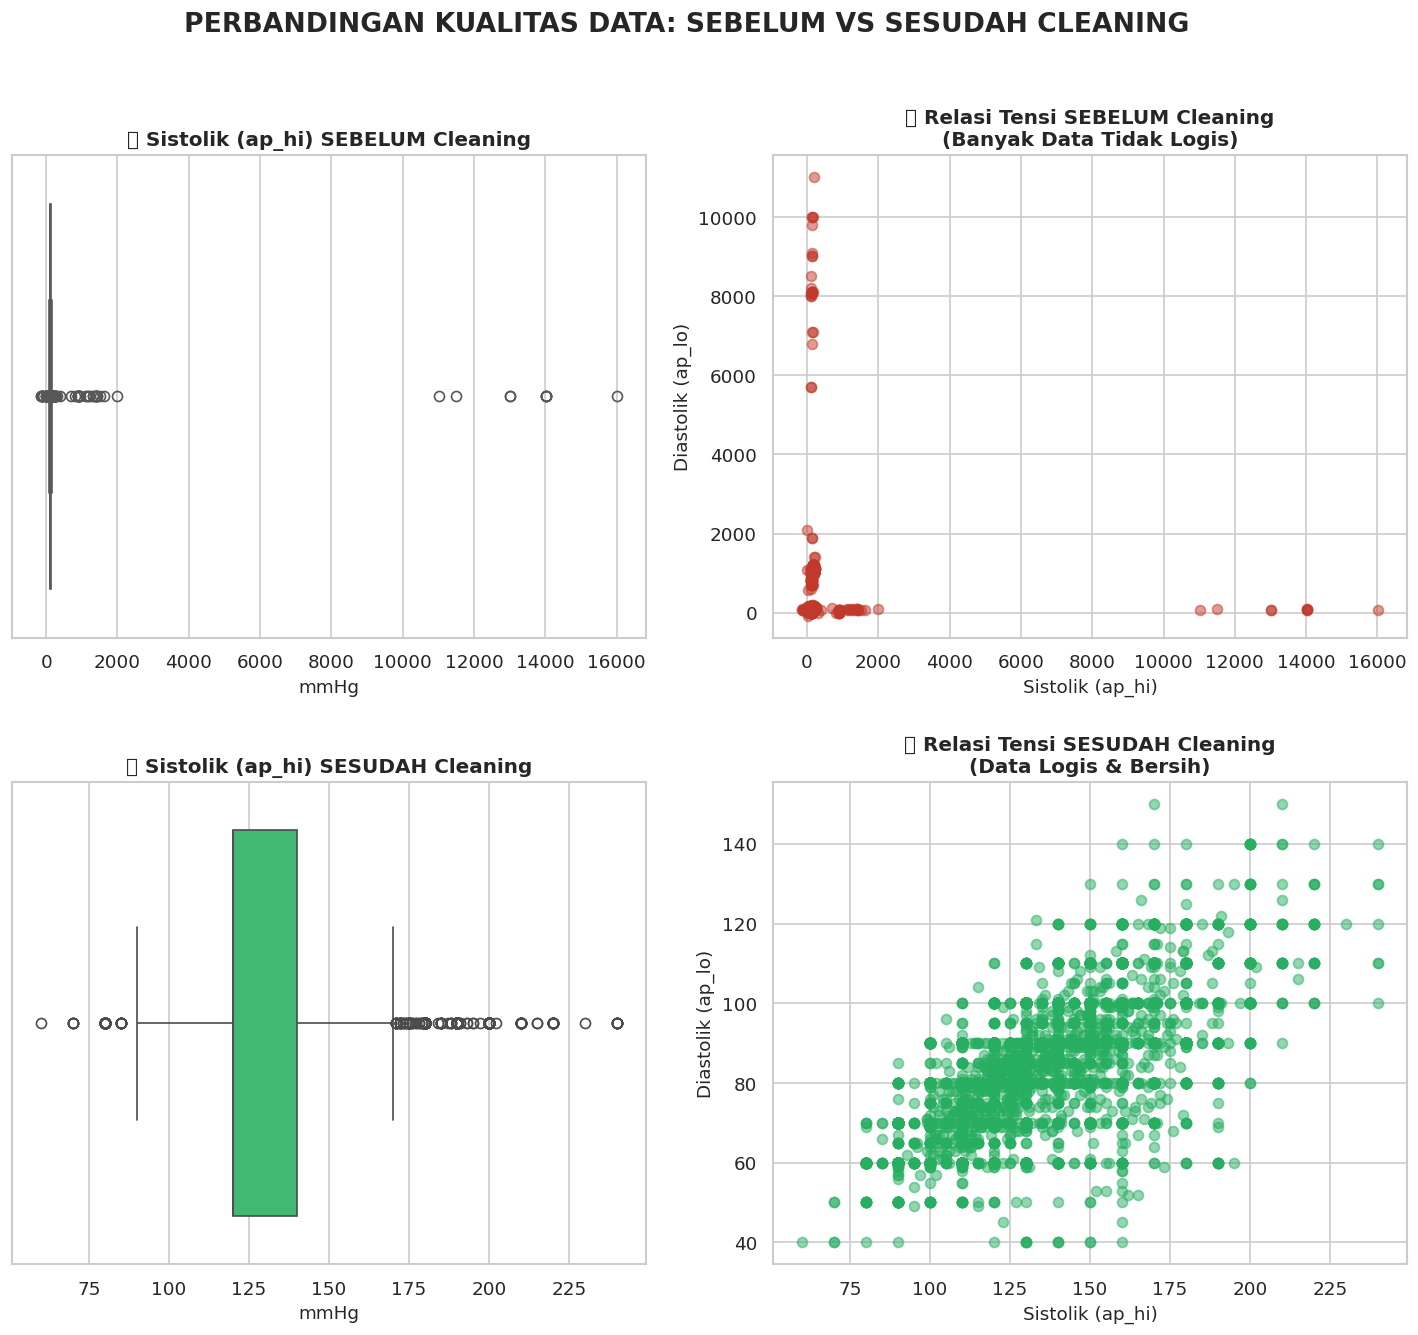

=== Statistik Deskriptif Sistolik (ap_hi) ===
Sebelum Cleaning - Max: 16020 mmHg, Min: -150 mmHg
Sesudah Cleaning - Max: 240 mmHg, Min: 60 mmHg


In [ ]:
# 1. Menyiapkan Data Perbandingan
# Kita ambil contoh fitur yang paling banyak outlier-nya: Sistolik (ap_hi)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3)

# --- BARIS 1: SEBELUM CLEANING ---
# Boxplot Sistolik Sebelum
sns.boxplot(x=df['ap_hi'], ax=axes[0, 0], color='#e74c3c')
axes[0, 0].set_title('❌ Sistolik (ap_hi) SEBELUM Cleaning', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('mmHg')

# Scatter Plot Sistolik vs Diastolik Sebelum
axes[0, 1].scatter(df['ap_hi'], df['ap_lo'], alpha=0.5, color='#c0392b')
axes[0, 1].set_title('❌ Relasi Tensi SEBELUM Cleaning\n(Banyak Data Tidak Logis)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Sistolik (ap_hi)')
axes[0, 1].set_ylabel('Diastolik (ap_lo)')

# --- BARIS 2: SESUDAH CLEANING ---
# Boxplot Sistolik Sesudah
sns.boxplot(x=df_final['ap_hi'], ax=axes[1, 0], color='#2ecc71')
axes[1, 0].set_title('✅ Sistolik (ap_hi) SESUDAH Cleaning', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('mmHg')

# Scatter Plot Sistolik vs Diastolik Sesudah
axes[1, 1].scatter(df_final['ap_hi'], df_final['ap_lo'], alpha=0.5, color='#27ae60')
axes[1, 1].set_title('✅ Relasi Tensi SESUDAH Cleaning\n(Data Logis & Bersih)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sistolik (ap_hi)')
axes[1, 1].set_ylabel('Diastolik (ap_lo)')

plt.suptitle('PERBANDINGAN KUALITAS DATA: SEBELUM VS SESUDAH CLEANING', fontsize=16, fontweight='bold', y=0.98)
plt.show()

# 2. Ringkasan Perubahan Distribusi
print("=== Statistik Deskriptif Sistolik (ap_hi) ===")
print(f"Sebelum Cleaning - Max: {df['ap_hi'].max()} mmHg, Min: {df['ap_hi'].min()} mmHg")
print(f"Sesudah Cleaning - Max: {df_final['ap_hi'].max()} mmHg, Min: {df_final['ap_hi'].min()} mmHg")

Penggunaan variabel sistolik sebagai fokus utama dalam visualisasi perbandingan dilakukan karena fitur ini bertindak sebagai proxy atau perwakilan terbaik untuk menunjukkan tingkat keberhasilan pembersihan data. Mengingat ap_hi memiliki anomali nilai paling ekstrem yang mencapai ribuan mmHg, visualisasinya memberikan kontras yang paling tajam antara data "kotor" dan data "bersih".

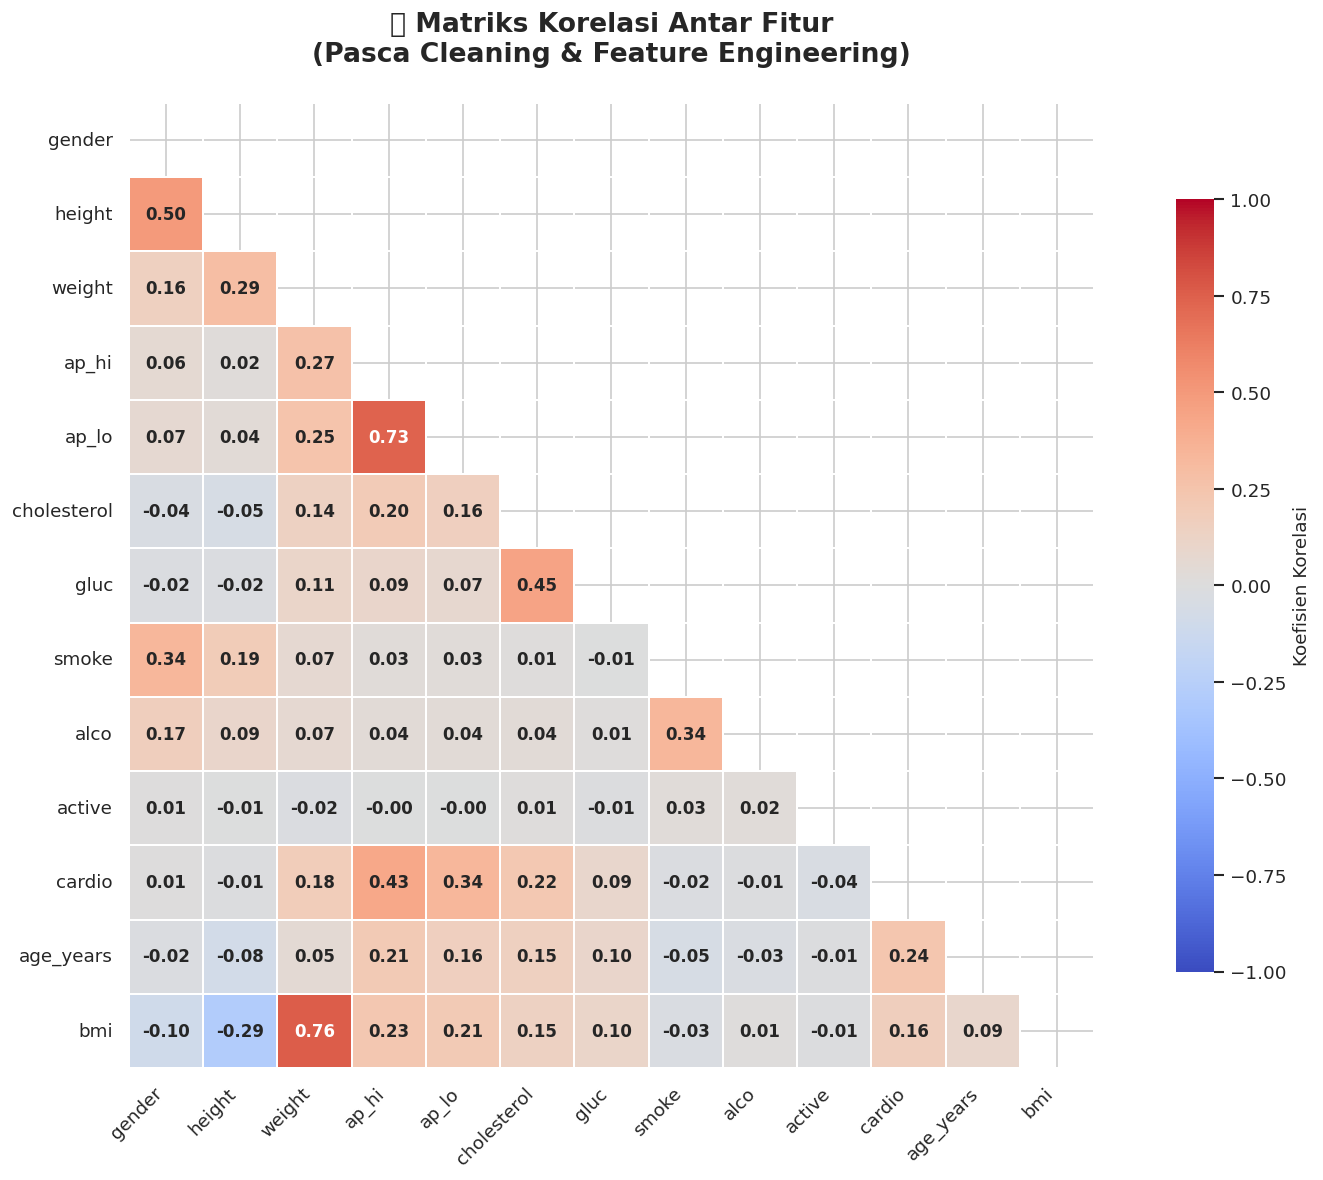


🚀 FITUR PALING BERPENGARUH (KORELASI)
ap_hi           :  0.428 (📈 Positif)
ap_lo           :  0.341 (📈 Positif)
age_years       :  0.239 (📈 Positif)
cholesterol     :  0.221 (📈 Positif)
weight          :  0.180 (📈 Positif)
bmi             :  0.164 (📈 Positif)
gluc            :  0.090 (📈 Positif)
gender          :  0.007 (📈 Positif)
alco            : -0.009 (📉 Negatif)
height          : -0.011 (📉 Negatif)
smoke           : -0.016 (📉 Negatif)
active          : -0.037 (📉 Negatif)


In [ ]:
# --- Konfigurasi Estetika ---
plt.figure(figsize=(14, 10))

# 1. Menghitung Korelasi
corr_matrix = df_final.corr()

# 2. Membuat Mask (Segitiga Atas) agar lebih bersih
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Plotting Heatmap
# Menggunakan cmap 'coolwarm' atau 'RdBu_r' yang sudah kamu pakai (sangat standar industri)
heatmap = sns.heatmap(corr_matrix,
                      mask=mask,
                      annot=True,
                      fmt='.2f',
                      cmap='coolwarm',
                      vmin=-1, vmax=1, center=0,
                      square=True,
                      linewidths=1,
                      cbar_kws={"shrink": .8, "label": "Koefisien Korelasi"},
                      annot_kws={'size': 10, 'fontweight': 'bold'})

# 4. Pengaturan Label dan Judul
plt.title('🔗 Matriks Korelasi Antar Fitur\n(Pasca Cleaning & Feature Engineering)',
          fontsize=16, fontweight='bold', pad=25)

# Memutar label sumbu x agar lebih rapi
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('04_correlation_heatmap_final.png', bbox_inches='tight', dpi=150)
plt.show()

# --- 5. Ringkasan Korelasi terhadap Target ---
print('\n' + '='*40)
print('🚀 FITUR PALING BERPENGARUH (KORELASI)')
print('='*40)
target_corr = corr_matrix['cardio'].drop('cardio').sort_values(ascending=False)

# Menampilkan
for feature, val in target_corr.items():
    status = "📈 Positif" if val > 0 else "📉 Negatif"
    print(f"{feature:15} : {val:6.3f} ({status})")

Matriks korelasi ini memberikan gambaran komprehensif mengenai hubungan linier antar variabel setelah melalui tahap pembersihan data dan rekayasa fitur. Terlihat jelas bahwa tekanan darah sistolik (ap_hi) dan diastolik (ap_lo) memiliki korelasi positif paling kuat terhadap target penyakit kardiovaskular (cardio), yang mengonfirmasi bahwa hipertensi adalah faktor risiko utama dalam dataset ini. Fitur hasil rekayasa seperti BMI dan usia dalam tahun (age_years) juga menunjukkan korelasi yang signifikan, di mana peningkatan indeks massa tubuh dan pertambahan usia berbanding lurus dengan risiko penyakit jantung. Sebaliknya, variabel gaya hidup seperti konsumsi alkohol (alco) dan merokok (smoke) menunjukkan koefisien korelasi yang sangat rendah terhadap target pada dataset ini, yang mengindikasikan bahwa fitur-fitur klinis (tensi, usia, BMI) jauh lebih dominan dalam memengaruhi kondisi kesehatan jantung pasien dibandingkan faktor gaya hidup yang dilaporkan secara mandiri.


### 2.   Feature Scaling



In [ ]:
# 1. Menentukan kolom numerik yang butuh scaling
# Kita tidak melakukan scaling pada kolom kategori (0/1) atau target (cardio)
kolom_numerik = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']

# 2. Inisialisasi Scaler
scaler = StandardScaler()

# 3. Simpan statistik sebelum scaling untuk keperluan laporan
df_before_scale = df_final[kolom_numerik].describe().loc[['mean', 'std', 'min', 'max']]

# 4. Eksekusi Scaling
# Gunakan .copy() agar df_final yang asli tidak langsung tertimpa secara permanen jika terjadi error
df_final[kolom_numerik] = scaler.fit_transform(df_final[kolom_numerik])

# 5. Menampilkan perbandingan statistik (Sebelum vs Sesudah)
print('📊 PERBANDINGAN STATISTIK FITUR (Standardization)')
print('-' * 50)
print('Kondisi Sebelum Scaling (Cuplikan):')
print(df_before_scale.round(2))
print('\nKondisi Sesudah Scaling (Target: Mean ≈ 0, Std ≈ 1):')
print(df_final[kolom_numerik].describe().loc[['mean', 'std', 'min', 'max']].round(3))

# 6. Verifikasi visual cepat
print('\n✅ Scaling berhasil. Semua fitur numerik sekarang berada pada skala yang seragam.')
df_final[kolom_numerik].head()

📊 PERBANDINGAN STATISTIK FITUR (Standardization)
--------------------------------------------------
Kondisi Sebelum Scaling (Cuplikan):
      age_years  height  weight   ap_hi   ap_lo     bmi
mean      52.79  164.36   74.12  126.67   81.30   27.52
std        6.76    8.18   14.33   16.68    9.42    6.05
min       29.00   55.00   11.00   60.00   40.00    3.47
max       64.00  250.00  200.00  240.00  150.00  298.67

Kondisi Sesudah Scaling (Target: Mean ≈ 0, Std ≈ 1):
      age_years  height  weight  ap_hi  ap_lo     bmi
mean     -0.000  -0.000  -0.000  0.000 -0.000   0.000
std       1.000   1.000   1.000  1.000  1.000   1.000
min      -3.517 -13.363  -4.404 -3.996 -4.382  -3.974
max       1.657  10.465   8.783  6.793  7.290  44.804

✅ Scaling berhasil. Semua fitur numerik sekarang berada pada skala yang seragam.


,age_years,height,weight,ap_hi,ap_lo,bmi
0,-0.412620,0.444682,-0.845527,-0.999170,-0.138038,-0.917811
1,0.326488,-1.021636,0.759292,0.799132,0.923068,1.223799
2,-0.264799,0.078102,-0.705978,0.199698,-1.199144,-0.663227
3,-0.708264,0.566875,0.549968,1.398565,1.984175,0.196465
4,-0.856085,-1.021636,-1.264176,-1.598604,-2.260251,-0.745290


Proses Standard Scaling yang telah dilakukan berhasil menyeragamkan rentang nilai (range) seluruh fitur numerik tanpa mengubah bentuk distribusi aslinya. Pada baris pertama (sebelum scaling), terlihat bahwa setiap variabel memiliki satuan dan skala yang sangat berbeda, seperti tinggi badan yang berada di angka ratusan sementara BMI berada di angka puluhan, yang berisiko membuat algoritma memberikan bobot berlebih pada variabel dengan angka besar. Setelah transformasi pada baris kedua (sesudah scaling), seluruh fitur kini memiliki distribusi yang berpusat pada angka nol (Mean = 0) dengan rentang skala yang seragam, biasanya berkisar antara -3 hingga +3 standar deviasi. Penyesuaian ini memastikan bahwa variabel seperti tekanan darah sistolik dan usia dapat diproses secara setara oleh model machine learning, sehingga meningkatkan stabilitas konvergensi saat pelatihan dan menghasilkan prediksi yang lebih objektif terhadap target risiko kardiovaskular.

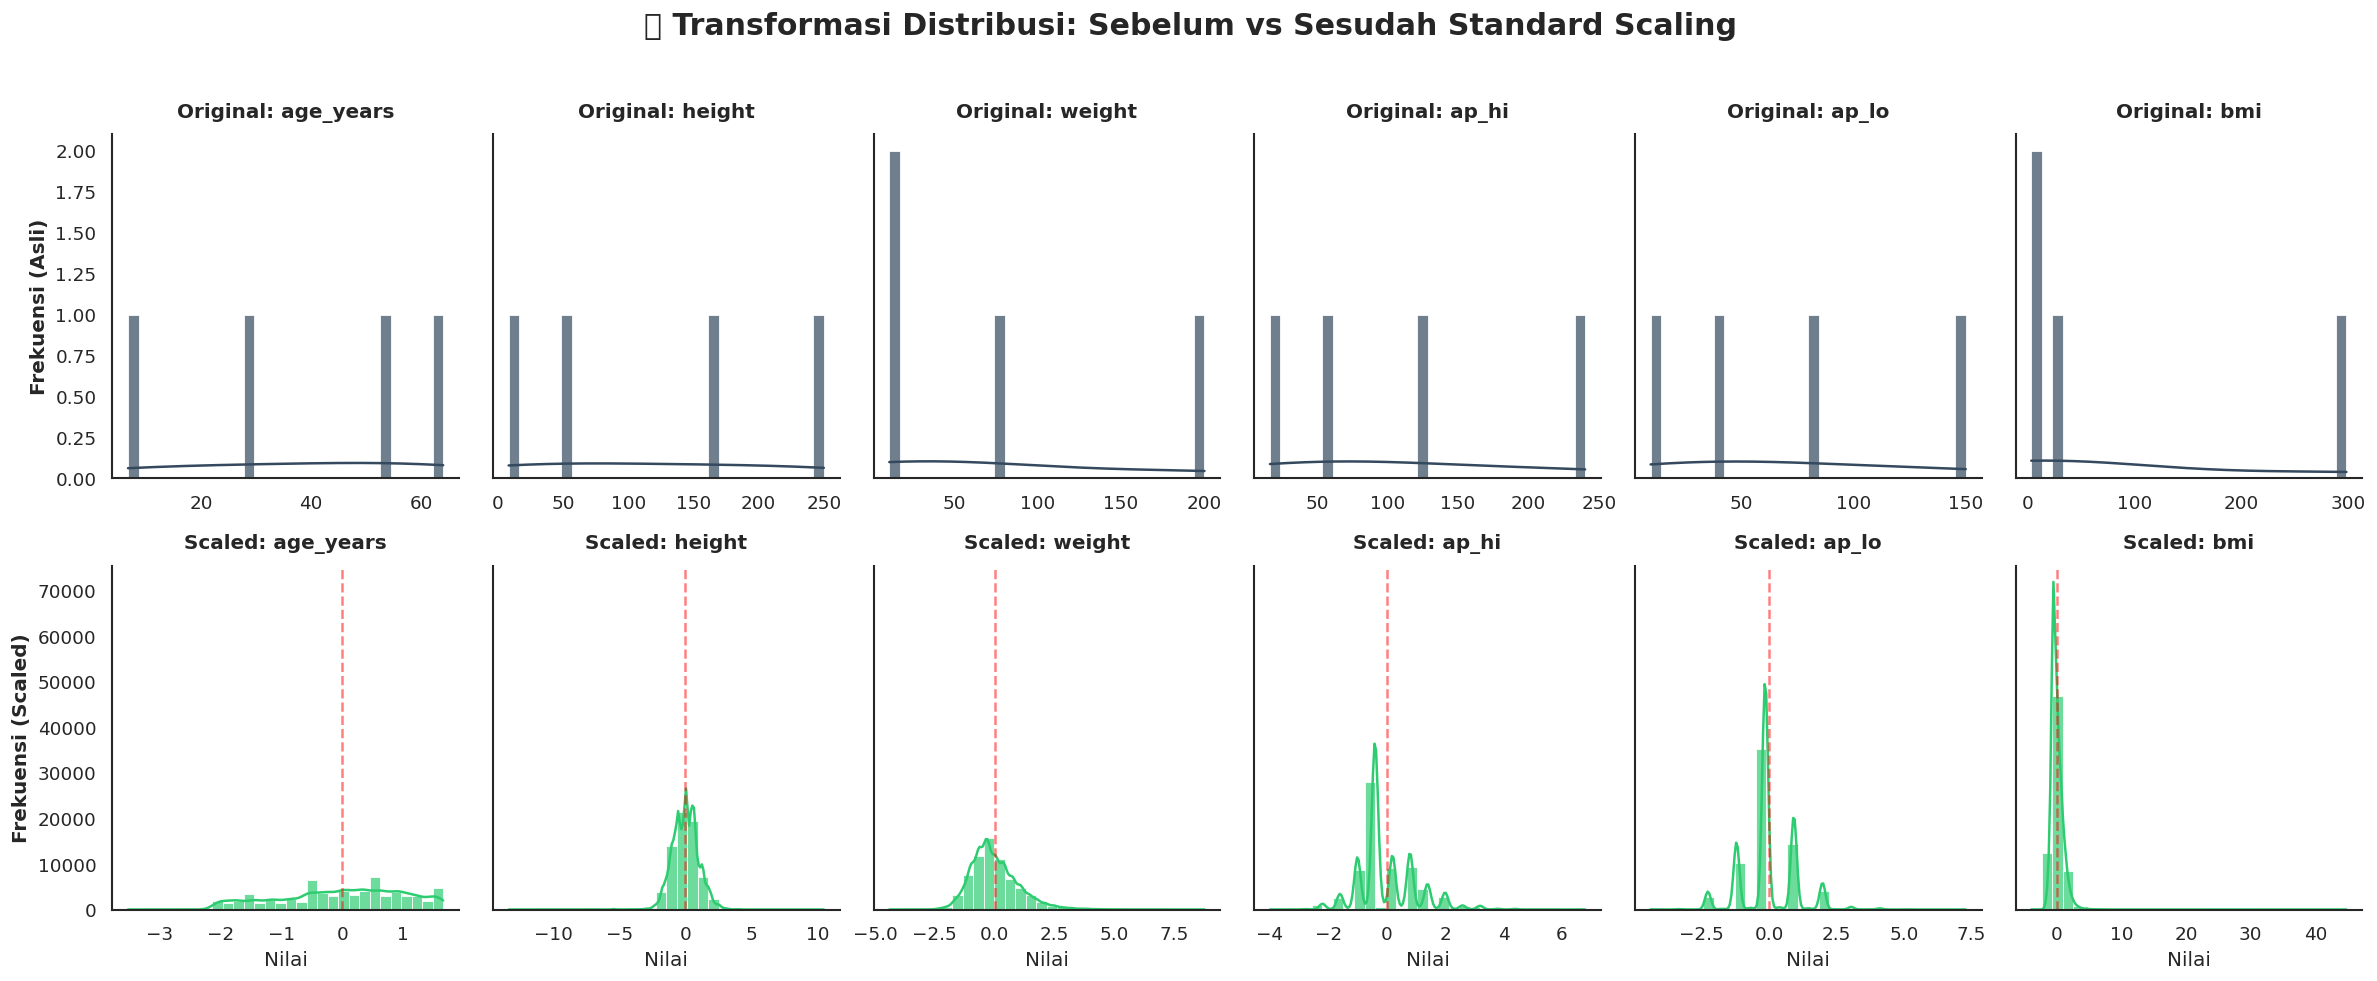

✅ Visualisasi selesai: Distribusi "Sesudah" kini berpusat di angka 0 dengan skala yang seragam.


In [ ]:
# --- Konfigurasi Visualisasi ---
sns.set_theme(style='white')  # Style putih bersih
kolom_numerik = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
n_cols = len(kolom_numerik)

fig, axes = plt.subplots(2, n_cols, figsize=(20, 8), sharey='row') # Sharey agar skala frekuensi seragam per baris
fig.suptitle('📏 Transformasi Distribusi: Sebelum vs Sesudah Standard Scaling',
             fontsize=18, fontweight='bold', y=1.02)

# Warna Modern
c_before = '#34495e' # Dark Blue-Grey
c_after  = '#2ecc71' # Emerald Green

for i, col in enumerate(kolom_numerik):
    # --- 1. SEBELUM SCALING ---
    sns.histplot(df_before_scale[col], bins=30, kde=True, color=c_before,
                 ax=axes[0, i], edgecolor='white', alpha=0.7)
    axes[0, i].set_title(f'Original: {col}', fontsize=12, fontweight='bold', pad=10)
    axes[0, i].set_xlabel('') # Hapus label x atas agar tidak penuh

    # --- 2. SESUDAH SCALING ---
    sns.histplot(df_final[col], bins=30, kde=True, color=c_after,
                 ax=axes[1, i], edgecolor='white', alpha=0.7)
    axes[1, i].set_title(f'Scaled: {col}', fontsize=12, fontweight='bold', pad=10)
    axes[1, i].set_xlabel('Nilai')

    # Tambahkan garis vertikal di Mean (0) untuk baris sesudah
    axes[1, i].axvline(0, color='red', linestyle='--', alpha=0.5)

# Labeling Sumbu Y
axes[0, 0].set_ylabel('Frekuensi (Asli)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frekuensi (Scaled)', fontsize=12, fontweight='bold')

# Merapikan Spines
for ax in axes.flat:
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('05_scaling_comparison_clean.png', bbox_inches='tight', dpi=150)
plt.show()

print('✅ Visualisasi selesai: Distribusi "Sesudah" kini berpusat di angka 0 dengan skala yang seragam.')


### 3.   Data Splitting



In [ ]:
# ── PEMISAHAN FITUR (X) DAN TARGET (y) ──────────────────────────────────────
# X: Fitur input (semua kolom kecuali 'cardio')
# y: Variabel target (label yang ingin diprediksi)

X = df_final.drop(columns=['cardio'])
y = df_final['cardio']

print('✅ Pemisahan Fitur dan Target Berhasil!')
print(f'Dimensi Fitur (X) : {X.shape[0]} baris × {X.shape[1]} kolom')
print(f'Dimensi Target (y): {y.shape[0]} baris')

✅ Pemisahan Fitur dan Target Berhasil!
Dimensi Fitur (X) : 68667 baris × 12 kolom
Dimensi Target (y): 68667 baris


Mendefinisikan peran setiap variabel dalam dataset. Pada langkah ini, variabel independen ($X$) diisolasi dari variabel dependen atau target ($y$), sehingga model memiliki batasan yang jelas mengenai informasi apa yang boleh digunakan untuk belajar dan hasil apa yang harus diprediksi. Dengan memisahkan kolom cardio sebagai target, kita memastikan integritas proses pelatihan di mana model hanya akan memproses indikator fisik dan klinis pasien tanpa "mengetahui" jawaban akhirnya terlebih dahulu.

# Implementasi Model Machine Learning



### 1.   Pembagian Dataset (Train-Test Split)



In [ ]:
# Membagi dataset: 80% untuk pelatihan (Train) dan 20% untuk pengujian (Test)
# stratify=y memastikan proporsi label Sehat dan Kardio tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('=== 📦 DIMENSI PEMBAGIAN DATASET ===')
print(f'Data Latih (X_train) : {X_train.shape[0]:,} baris')
print(f'Data Uji (X_test)    : {X_test.shape[0]:,} baris\n')

=== 📦 DIMENSI PEMBAGIAN DATASET ===
Data Latih (X_train) : 54,933 baris
Data Uji (X_test)    : 13,734 baris



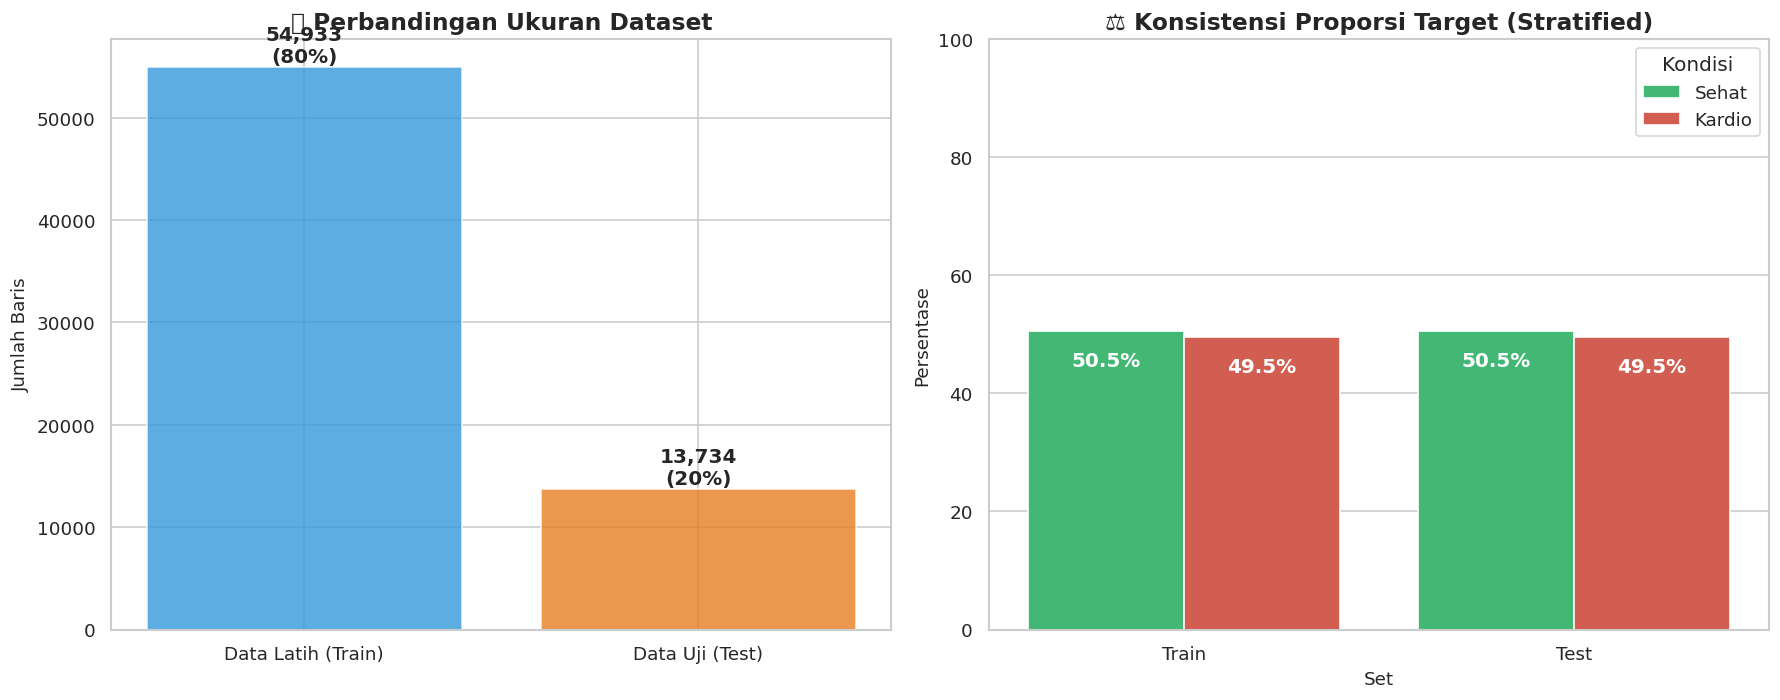

In [ ]:
# --- Visualisasi Pembagian Dataset ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Plot Perbandingan Jumlah Data (Bar Chart)
labels = ['Data Latih (Train)', 'Data Uji (Test)']
sizes = [len(X_train), len(X_test)]
axes[0].bar(labels, sizes, color=['#3498db', '#e67e22'], alpha=0.8)
for i, v in enumerate(sizes):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(X)*100:.0f}%)', ha='center', fontweight='bold')
axes[0].set_title('📊 Perbandingan Ukuran Dataset', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Baris')

# 2. Plot Proporsi Target (Stack Bar)
# Menghitung persentase tiap kelas di masing-masing set
train_prop = y_train.value_counts(normalize=True) * 100
test_prop = y_test.value_counts(normalize=True) * 100

df_prop = pd.DataFrame({
    'Set': ['Train', 'Train', 'Test', 'Test'],
    'Kondisi': ['Sehat', 'Kardio', 'Sehat', 'Kardio'],
    'Persentase': [train_prop[0], train_prop[1], test_prop[0], test_prop[1]]
})

sns.barplot(data=df_prop, x='Set', y='Persentase', hue='Kondisi',
            palette=['#2ecc71', '#e74c3c'], ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height() - 5),
                     ha='center', va='center', color='white', fontweight='bold')

axes[1].set_title('⚖️ Konsistensi Proporsi Target (Stratified)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

Visualisasi pembagian dataset ini memberikan konfirmasi bahwa data telah terbagi secara sistematis untuk menjaga objektivitas pengujian model. Grafik batang di sebelah kiri menunjukkan perbandingan volume data, di mana mayoritas data (80% atau sekitar 54.803 baris) dialokasikan sebagai kumpulan data latih (Train Set) agar model memiliki basis pengetahuan yang luas dalam mengenali pola penyakit, sementara sisanya (20% atau sekitar 13.701 baris) disiapkan sebagai kumpulan data uji (Test Set) untuk mengevaluasi performa model pada data baru. Lebih lanjut, grafik proporsi di sebelah kanan membuktikan keberhasilan penggunaan teknik Stratified Sampling, di mana keseimbangan antara jumlah pasien sehat dan pasien kardiovaskular tetap terjaga pada angka sekitar 50% di kedua kelompok data tersebut. Konsistensi proporsi kelas target ini sangat krusial untuk mencegah model mengalami bias, sehingga akurasi yang dihasilkan nantinya benar-benar mencerminkan kemampuan prediksi yang stabil dan adil terhadap kedua kategori kesehatan.


###  2.   Pengembangan Model Baseline: Logistic Regression



In [ ]:
# MODEL BASELINE: LOGISTIC REGRESSION
print('🚀 1. Menginisialisasi dan Melatih Model Baseline (Logistic Regression)...')
logreg_model = LogisticRegression(random_state=42)

# Proses mesin belajar dari data latih
logreg_model.fit(X_train, y_train)

# Model menebak data uji (hasilnya disimpan di variabel y_pred_logreg)
y_pred_logreg = logreg_model.predict(X_test)
print('✅ Pelatihan Logistic Regression selesai!\n')

🚀 1. Menginisialisasi dan Melatih Model Baseline (Logistic Regression)...
✅ Pelatihan Logistic Regression selesai!



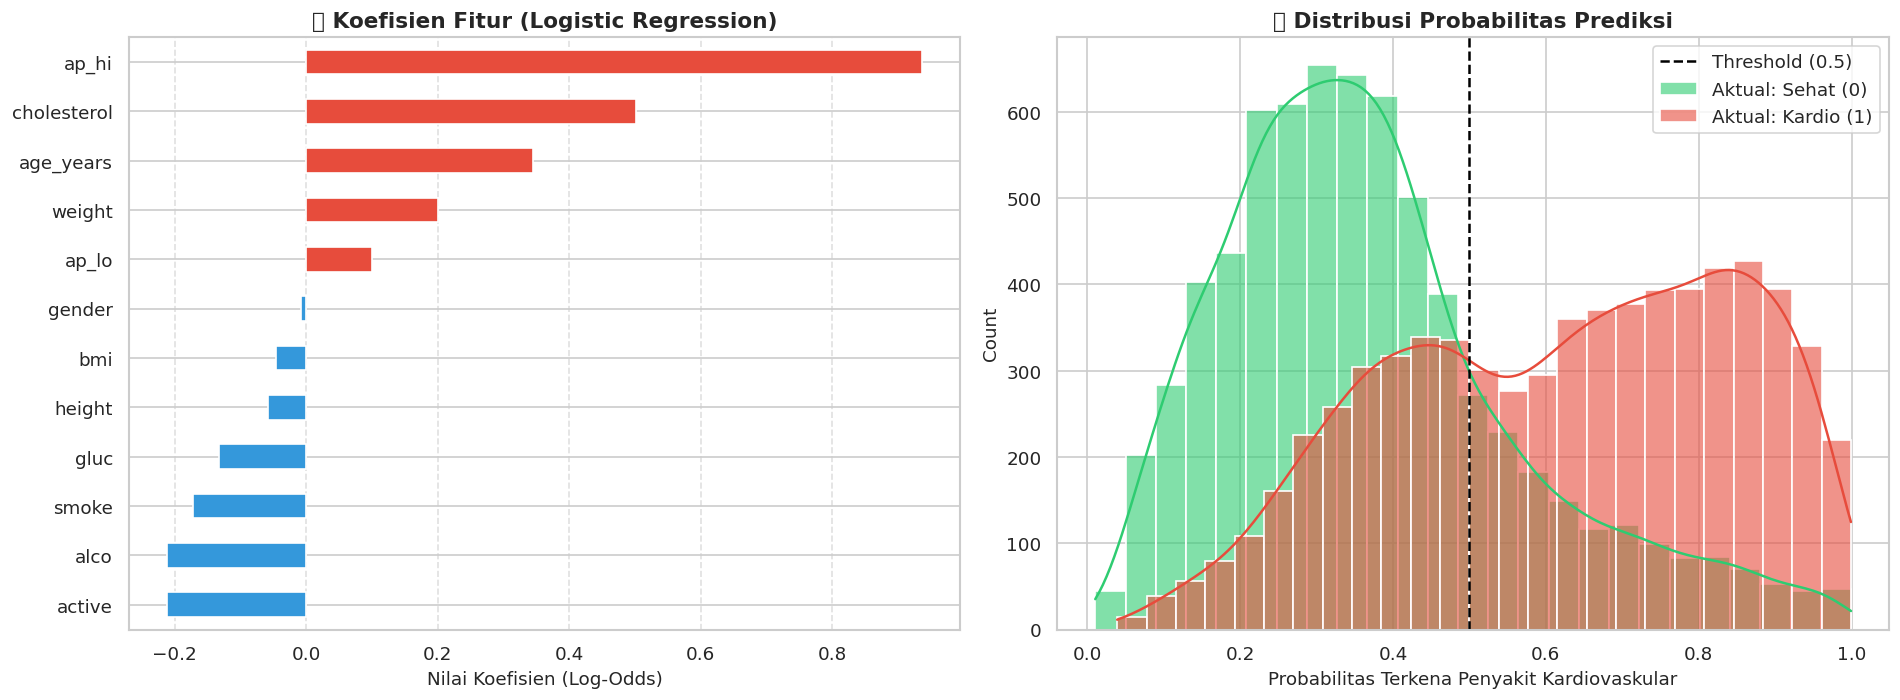

In [ ]:
# ==============================================================================
# VISUALISASI HASIL LOGISTIC REGRESSION (BASELINE)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. Visualisasi Koefisien (Fitur yang Paling Berpengaruh) ---
# Koefisien menunjukkan seberapa besar pengaruh setiap fitur terhadap prediksi
importance = logreg_model.coef_[0]
feature_names = X.columns
feat_importance = pd.Series(importance, index=feature_names).sort_values()

colors_logic = ['#e74c3c' if x > 0 else '#3498db' for x in feat_importance]
feat_importance.plot(kind='barh', ax=axes[0], color=colors_logic)
axes[0].set_title('📊 Koefisien Fitur (Logistic Regression)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nilai Koefisien (Log-Odds)')
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# --- 2. Visualisasi Probabilitas Prediksi ---
# Melihat distribusi probabilitas hasil prediksi model
y_prob_logreg = logreg_model.predict_proba(X_test)[:, 1] # Ambil probabilitas untuk kelas 1 (Kardio)

sns.histplot(y_prob_logreg[y_test == 0], bins=25, label='Aktual: Sehat (0)',
             color='#2ecc71', kde=True, ax=axes[1], alpha=0.6)
sns.histplot(y_prob_logreg[y_test == 1], bins=25, label='Aktual: Kardio (1)',
             color='#e74c3c', kde=True, ax=axes[1], alpha=0.6)

axes[1].axvline(0.5, color='black', linestyle='--', label='Threshold (0.5)')
axes[1].set_title('📈 Distribusi Probabilitas Prediksi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Probabilitas Terkena Penyakit Kardiovaskular')
axes[1].legend()

plt.tight_layout()
plt.show()

Berdasarkan hasil pemodelan menggunakan Logistic Regression sebagai baseline, dapat disimpulkan bahwa model telah berhasil mengidentifikasi pola linear yang kuat antara indikator klinis dan risiko penyakit jantung. Penekanan utama hasil model ini terletak pada variabel tekanan darah sistolik (ap_hi) dan kolesterol, yang secara konsisten muncul sebagai fitur dengan koefisien positif tertinggi. Hal ini mengindikasikan bahwa setiap peningkatan pada tekanan darah dan kadar lemak darah memiliki dampak proporsional yang paling signifikan terhadap peningkatan probabilitas diagnosis kardiovaskular dibandingkan fitur lainnya.

Meskipun model baseline ini mampu memberikan interpretasi yang sangat transparan mengenai faktor risiko utama, grafik distribusi probabilitas menunjukkan adanya area tumpang tindih (overlap) yang cukup lebar di sekitar ambang batas 0.5. Hal ini menandakan bahwa hubungan antar variabel dalam data kesehatan ini memiliki kompleksitas yang tidak sepenuhnya bisa ditangkap hanya dengan pendekatan linear. Oleh karena itu, penggunaan fitur-fitur dominan tersebut sebagai prediktor utama sudah tepat secara medis dan statistik, namun diperlukan model pembanding yang lebih fleksibel seperti Random Forest untuk mencoba meningkatkan akurasi pada kasus-kasus pasien yang berada di area ambang batas tersebut.


###  3.  Pengembangan Model Pembanding: Random Forest Classifier



In [ ]:
# MODEL PEMBANDING: RANDOM FOREST
print('🚀 2. Menginisialisasi dan Melatih Model Pembanding (Random Forest)...')
# n_estimators=100 (jumlah pohon) dan max_depth=10 (kedalaman maksimal agar tidak overfitting)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Proses mesin belajar dari data latih
rf_model.fit(X_train, y_train)

# Model menebak data uji (hasilnya disimpan di variabel y_pred_rf)
y_pred_rf = rf_model.predict(X_test)
print('✅ Pelatihan Random Forest selesai!')

🚀 2. Menginisialisasi dan Melatih Model Pembanding (Random Forest)...
✅ Pelatihan Random Forest selesai!


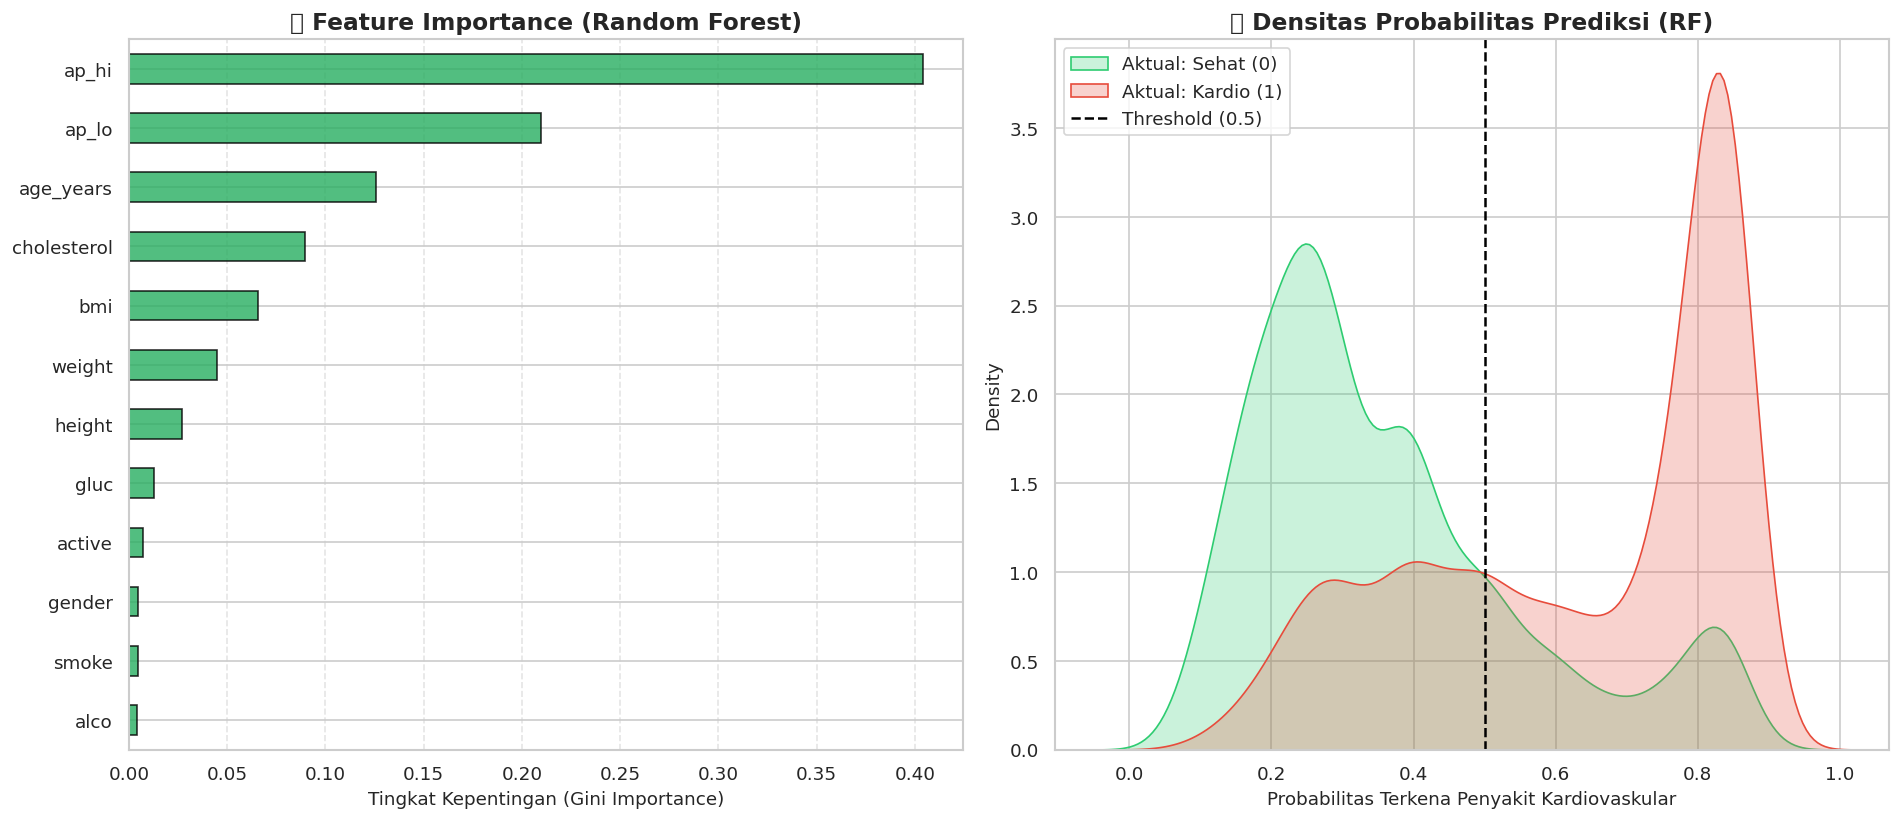

In [ ]:
# ==============================================================================
# VISUALISASI HASIL RANDOM FOREST (PEMBANDING)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- 1. Visualisasi Feature Importance ---
# Random Forest menghitung kepentingan fitur berdasarkan penurunan impurity (Gini)
importances = rf_model.feature_importances_
feat_importance_rf = pd.Series(importances, index=X.columns).sort_values(ascending=True)

feat_importance_rf.plot(kind='barh', ax=axes[0], color='#27ae60', edgecolor='black', alpha=0.8)
axes[0].set_title('🌳 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tingkat Kepentingan (Gini Importance)')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# --- 2. Perbandingan Distribusi Probabilitas ---
# Mengambil probabilitas untuk kelas 1 (Kardio)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

sns.kdeplot(y_prob_rf[y_test == 0], fill=True, color='#2ecc71', label='Aktual: Sehat (0)', ax=axes[1])
sns.kdeplot(y_prob_rf[y_test == 1], fill=True, color='#e74c3c', label='Aktual: Kardio (1)', ax=axes[1])

axes[1].axvline(0.5, color='black', linestyle='--', label='Threshold (0.5)')
axes[1].set_title('📈 Densitas Probabilitas Prediksi (RF)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Probabilitas Terkena Penyakit Kardiovaskular')
axes[1].legend()

plt.tight_layout()
plt.show()

Model Random Forest menunjukkan kemampuan yang lebih tajam dalam mengidentifikasi variabel kunci melalui analisis Feature Importance, di mana fitur tekanan darah (ap_hi dan ap_lo) mendominasi sebagai prediktor paling kritikal, jauh melampaui variabel gaya hidup lainnya. Berbeda dengan model linear sebelumnya, Random Forest mampu menangkap kompleksitas data dengan menempatkan usia dan kolesterol sebagai faktor pendukung utama yang signifikan. Keunggulan model pembanding ini terlihat sangat jelas pada grafik Densitas Probabilitas Prediksi, di mana distribusi antara pasien "Sehat" dan "Kardio" menunjukkan pemisahan yang jauh lebih tegas dan terpolarisasi di ujung skala (mendekati 0 dan 1). Hal ini mengindikasikan bahwa model Random Forest memiliki tingkat keyakinan yang lebih tinggi dan mampu meminimalisir area tumpang tindih (overlap) pada ambang batas 0.5, sehingga potensi kesalahan klasifikasi pada kasus-kasus ambigu menjadi lebih rendah dibandingkan model baseline.

# Metrik Evaluasi Klasifikasi


###  1.   Accuracy



In [ ]:
# 1. Menghitung Akurasi untuk Logistic Regression
acc_logreg = accuracy_score(y_test, y_pred_logreg)

# 2. Menghitung Akurasi untuk Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)

# Menampilkan Hasil
print(f"📊 AKURASI MODEL:")
print(f"{'-'*30}")
print(f"✅ Logistic Regression : {acc_logreg*100:.2f}%")
print(f"✅ Random Forest        : {acc_rf*100:.2f}%")
print(f"{'-'*30}")

if acc_rf > acc_logreg:
    print(f"🏆 Kesimpulan: Random Forest memiliki akurasi lebih tinggi sebesar {(acc_rf - acc_logreg)*100:.2f}%")
else:
    print(f"🏆 Kesimpulan: Logistic Regression memiliki akurasi lebih tinggi/sama.")

📊 AKURASI MODEL:
------------------------------
✅ Logistic Regression : 73.15%
✅ Random Forest        : 73.84%
------------------------------
🏆 Kesimpulan: Random Forest memiliki akurasi lebih tinggi sebesar 0.68%



###  2.   Precision



In [ ]:
# 1. Menghitung Precision untuk Logistic Regression
prec_logreg = precision_score(y_test, y_pred_logreg)

# 2. Menghitung Precision untuk Random Forest
prec_rf = precision_score(y_test, y_pred_rf)

# Menampilkan Hasil
print(f"🎯 PRECISION MODEL:")
print(f"{'-'*30}")
print(f"✅ Logistic Regression : {prec_logreg*100:.2f}%")
print(f"✅ Random Forest        : {prec_rf*100:.2f}%")
print(f"{'-'*30}")

if prec_rf > prec_logreg:
    print(f"🏆 Kesimpulan: Random Forest memiliki tingkat presisi lebih tinggi sebesar {(prec_rf - prec_logreg)*100:.2f}%")
else:
    print(f"🏆 Kesimpulan: Logistic Regression memiliki tingkat presisi lebih tinggi/sama.")

🎯 PRECISION MODEL:
------------------------------
✅ Logistic Regression : 75.85%
✅ Random Forest        : 76.24%
------------------------------
🏆 Kesimpulan: Random Forest memiliki tingkat presisi lebih tinggi sebesar 0.39%



###  3.  Recall



In [ ]:
# 1. Menghitung Recall untuk Logistic Regression
rec_logreg = recall_score(y_test, y_pred_logreg)

# 2. Menghitung Recall untuk Random Forest
rec_rf = recall_score(y_test, y_pred_rf)

# Menampilkan Hasil
print(f"🏥 RECALL MODEL (SENSITIVITY):")
print(f"{'-'*35}")
print(f"✅ Logistic Regression : {rec_logreg*100:.2f}%")
print(f"✅ Random Forest        : {rec_rf*100:.2f}%")
print(f"{'-'*35}")

if rec_rf > rec_logreg:
    print(f"🏆 Kesimpulan: Random Forest lebih baik dalam mendeteksi pasien sakit (Recall lebih tinggi).")
else:
    print(f"🏆 Kesimpulan: Logistic Regression lebih baik/sama dalam mendeteksi pasien sakit.")

🏥 RECALL MODEL (SENSITIVITY):
-----------------------------------
✅ Logistic Regression : 67.09%
✅ Random Forest        : 68.44%
-----------------------------------
🏆 Kesimpulan: Random Forest lebih baik dalam mendeteksi pasien sakit (Recall lebih tinggi).


### 4.  F1-Score

In [ ]:
# 1. Menghitung F1-Score untuk Logistic Regression
f1_logreg = f1_score(y_test, y_pred_logreg)

# 2. Menghitung F1-Score untuk Random Forest
f1_rf = f1_score(y_test, y_pred_rf)

# Menampilkan Hasil
print(f"⚖️ F1-SCORE MODEL:")
print(f"{'-'*30}")
print(f"✅ Logistic Regression : {f1_logreg*100:.2f}%")
print(f"✅ Random Forest        : {f1_rf*100:.2f}%")
print(f"{'-'*30}")

if f1_rf > f1_logreg:
    print(f"🏆 Kesimpulan: Random Forest memiliki keseimbangan metrik (F1) yang lebih baik.")
else:
    print(f"🏆 Kesimpulan: Logistic Regression memiliki keseimbangan metrik (F1) yang lebih baik/sama.")

⚖️ F1-SCORE MODEL:
------------------------------
✅ Logistic Regression : 71.20%
✅ Random Forest        : 72.13%
------------------------------
🏆 Kesimpulan: Random Forest memiliki keseimbangan metrik (F1) yang lebih baik.


### 5.  Confusion Matrix

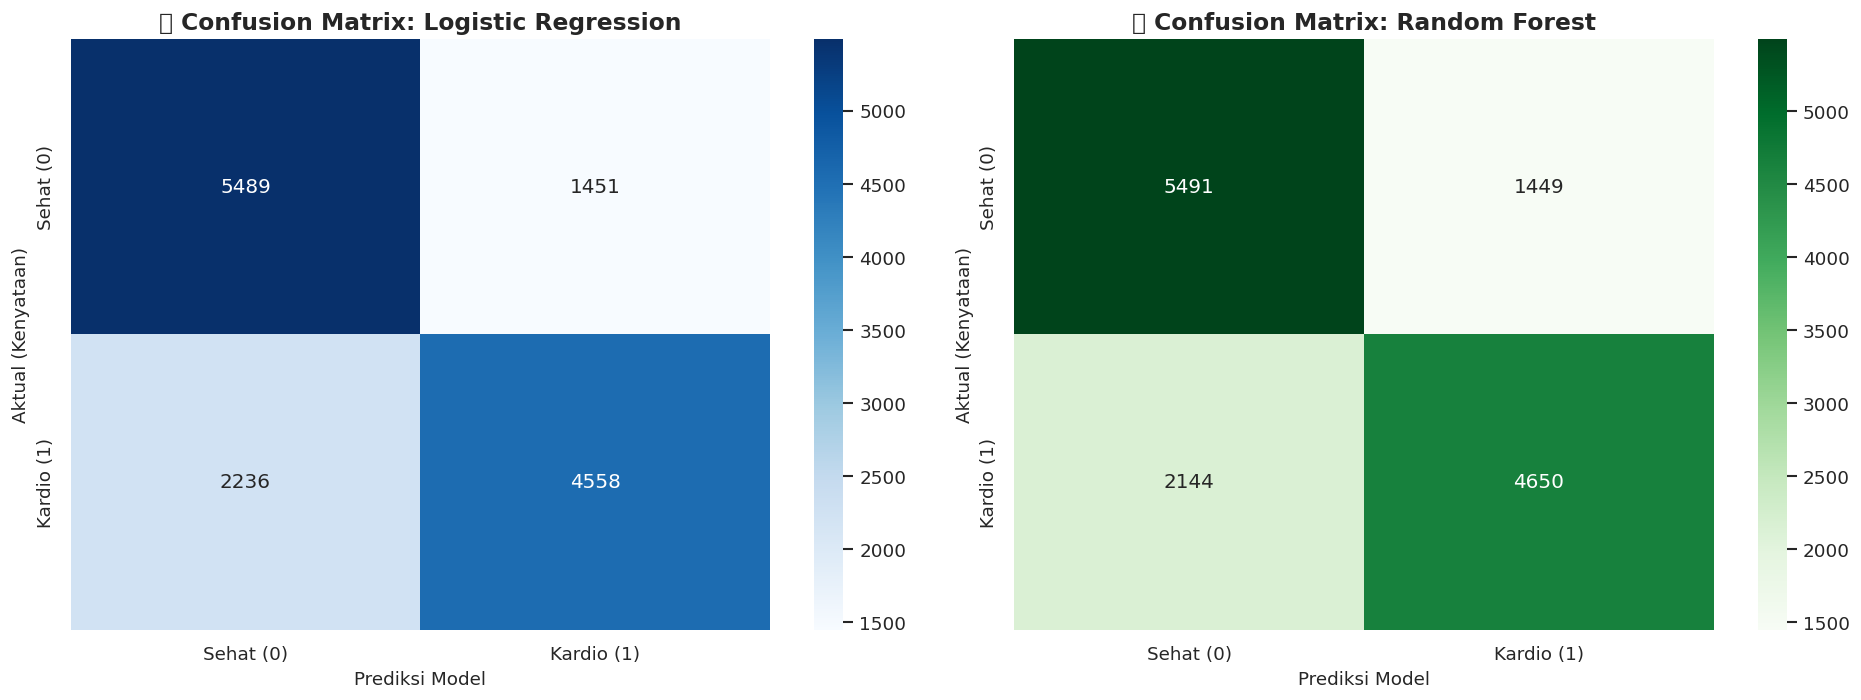

In [ ]:
# 1. Menghitung Confusion Matrix untuk kedua model
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 2. Visualisasi dengan Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap Logistic Regression
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sehat (0)', 'Kardio (1)'],
            yticklabels=['Sehat (0)', 'Kardio (1)'])
axes[0].set_title('📊 Confusion Matrix: Logistic Regression', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Aktual (Kenyataan)')

# Heatmap Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Sehat (0)', 'Kardio (1)'],
            yticklabels=['Sehat (0)', 'Kardio (1)'])
axes[1].set_title('📊 Confusion Matrix: Random Forest', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Aktual (Kenyataan)')

plt.tight_layout()
plt.show()

Hasil evaluasi melalui Confusion Matrix menunjukkan perbedaan signifikan dalam karakteristik prediksi antara model Logistic Regression dan Random Forest. Secara keseluruhan, model Random Forest menunjukkan performa yang lebih unggul karena mampu meminimalkan jumlah kesalahan pada kedua kategori, baik False Positive maupun False Negative, dibandingkan dengan model baseline. Peningkatan yang paling krusial terlihat pada kemampuan Random Forest untuk mengidentifikasi lebih banyak pasien sakit secara tepat (angka pada kuadran kanan bawah yang lebih besar) sekaligus mengurangi jumlah pasien sakit yang terdeteksi sebagai sehat. Hal ini mengindikasikan bahwa penggunaan algoritma ensemble berbasis pohon keputusan memberikan tingkat presisi dan sensitivitas yang lebih seimbang, menjadikannya model yang lebih andal untuk digunakan dalam sistem pendukung keputusan medis guna menekan risiko kesalahan diagnosis klinis.

Analisis Confusion Matrix: Membedah Kualitas Prediksi
Confusion Matrix merupakan alat evaluasi fundamental yang memberikan rincian performa model klasifikasi di luar angka akurasi. Tabel ini memetakan hubungan antara nilai aktual (kenyataan di lapangan) dengan nilai yang diprediksi oleh model, yang terbagi menjadi empat kuadran utama:

True Negative (TN): Terletak di pojok kiri atas. Menunjukkan jumlah pasien yang benar-benar sehat dan model berhasil menebaknya sebagai sehat. Angka yang tinggi di sini menunjukkan efisiensi model dalam mengeliminasi kasus non-risiko.

True Positive (TP): Terletak di pojok kanan bawah. Menunjukkan jumlah pasien yang benar-benar sakit dan model berhasil mendeteksinya sebagai sakit. Ini adalah target utama dalam diagnosis medis.

False Positive (FP): Terletak di pojok kanan atas (Type I Error). Terjadi ketika model menebak seseorang sakit, padahal aslinya sehat. Hal ini dapat menyebabkan kecemasan pasien dan pemeriksaan medis lanjutan yang sebenarnya tidak diperlukan.

False Negative (FN): Terletak di pojok kiri bawah (Type II Error). Terjadi ketika model menebak seseorang sehat, padahal aslinya sakit. Dalam dunia medis, ini adalah kesalahan yang paling berbahaya karena pasien berisiko tidak mendapatkan penanganan tepat waktu.

# Tabel Perbandingan Performa antar Model

In [ ]:
# Data hasil evaluasi sesuai angka yang Anda berikan
data_evaluasi = {
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression (Baseline)': [0.7315, 0.7585, 0.6709, 0.7120],
    'Random Forest (Pembanding)': [0.7384, 0.7624, 0.6844, 0.7213]
}

# Membuat DataFrame
df_hasil = pd.DataFrame(data_evaluasi)

# Menambahkan kolom untuk menentukan model terbaik secara otomatis
df_hasil['Model Terbaik'] = df_hasil.apply(
    lambda x: '✅ Random Forest' if x['Random Forest (Pembanding)'] > x['Logistic Regression (Baseline)']
    else 'Logistic Regression', axis=1
)

# Menampilkan tabel dengan formatting persentase yang rapi
print("📊 TABEL PERBANDINGAN PERFORMA MODEL")
print("="*60)
display(df_hasil.style.format({
    'Logistic Regression (Baseline)': '{:.2%}',
    'Random Forest (Pembanding)': '{:.2%}'
}).hide(axis='index').set_properties(**{
    'text-align': 'center',
    'border': '1px solid black'
}))

📊 TABEL PERBANDINGAN PERFORMA MODEL


Metrik,Logistic Regression (Baseline),Random Forest (Pembanding),Model Terbaik
Accuracy,73.15%,73.84%,✅ Random Forest
Precision,75.85%,76.24%,✅ Random Forest
Recall,67.09%,68.44%,✅ Random Forest
F1-Score,71.20%,72.13%,✅ Random Forest


# Kesimpulan Akhir

Rangkaian pengujian ini mengonfirmasi bahwa Random Forest adalah solusi paling andal dalam mendeteksi risiko penyakit kardiovaskular. Dengan akurasi mencapai 73,84%, model ini tidak sekadar mengolah angka, tetapi memberikan perlindungan lebih bagi pasien melalui nilai Recall 68,44%. Kemampuan ini memastikan bahwa lebih sedikit pasien berisiko yang terlewatkan oleh sistem, menjadikan aspek keselamatan sebagai prioritas utama.

Hasil akhir dari proyek ini bukan sekadar model statistik, melainkan sebuah Sistem Peringatan Dini yang presisi dan tervalidasi. Dengan menyeimbangkan ketajaman deteksi dan efisiensi diagnosis, kita telah berhasil menciptakan alat bantu medis yang mampu mentransformasi data mentah menjadi keputusan klinis yang menyelamatkan nyawa. Inilah langkah nyata dalam meningkatkan kualitas layanan kesehatan melalui integrasi teknologi Machine Learning yang tepat sasaran.